# Parallel Mean-Cov Model

## Imports and Setup

In [18]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import copy
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import shap
import torch

from lightning.pytorch.utilities.warnings import PossibleUserWarning
from scipy import stats
from scipy.stats import wilcoxon
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

from matplotlib.colors import LinearSegmentedColormap

white_red = LinearSegmentedColormap.from_list(
    "white_to_shap_red",
    ["white", "#FFB3C7", "#FF0051"],
)
blue_red = LinearSegmentedColormap.from_list(
    "blue_to_red",
    ["#008BFB", "#FFFFFF", "#FF0051"],
)



from src.classes import Anscombe, DotDict

from src.helper_functions import (
    build_lit_model,
    compute_correlation,
    compute_group_influence_matrix,
    compute_group_metrics,
    compute_metrics,
    compute_mse,
    compute_r2,
    compute_shap_values,
    load_cache,
    predict_loader,
    predict_loader_group_conditionings,
    prepare_dataset,
    prepare_loader,
    save_cache,
    seed_everything,
    shuffle_dataset,
)

from src.plot_functions import (
    get_cov_loading_matrices,
    get_cov_length_scales,
    get_covariance_matrix,
    plot_covariance_matrix_by_unit,
    plot_unit_spikes,
    plot_unit_covariance,
    plot_cov_length_scales,
    plot_cov_loading_matrix,
    plot_cov_noise,
    plot_covariance_matrix,
    plot_group_influence_matrix,
    plot_model_metric_improvement,
    plot_model_metrics_comparison,
    plot_prediction,
    plot_shap,
    plot_shap_hist,
    plot_spike_summary,
    plot_train_valid_metrics_comparison,
    plot_training_history,
    plot_variable_selectivity_hist,
    plot_variable_selectivity_curves,
    plot_variable_selectivity_pca,
    plot_class_selectivity_pca,
    plot_variable_selectivity_matrix,
    plot_class_selectivity_matrix,
    save_shap_plot,
)

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")

SEED = 1
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [19]:
Conf = DotDict({
    "run_id": 1,
    "seed": SEED,
    "paths": {
        "data": "data.mat",
    },
    "session_idx": 15,
    "device": device,
    "data": {
        "start_time": -2,
        "end_time": 2,
    },
    "training": {
        "batch_size": 32,
        "max_epoch": 500,
        "min_delta": 1e-4,
        "patience": 10,
        "n_shuffles": 100,
        "n_permutations": 100,
    },
    "model_type": {
        "name": "mean",
        "mean": {
            "n_hidden": 16,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
        "cov": {
            "n_latent": 16,
            "n_hidden": 2,
            "n_heads": 1,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
    },
    "optimization": {
        "Adam": {
            "lr": 0.01,
            "weight_decay": 0,
        },
        "Reduce": {
            "factor": 0.5,
            "patience":5,
            "min_lr": 1e-10,
        },
    }
})

## Data Preparation

In [20]:
data = sio.loadmat(Conf.paths.data, squeeze_me=True, struct_as_record=False)

session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

start_idx = np.searchsorted(bin_times, Conf.data.start_time, side='left')
end_idx = np.searchsorted(bin_times, Conf.data.end_time, side='right')

spikes = spikes[:, :, start_idx:end_idx]
position_vars = position_vars[:, :, start_idx:end_idx]
bin_times = bin_times[start_idx:end_idx]

dense = [0, 1, 2]
sparse = [3, 4, 5]

Conf.data.bin_size = bin_size
Conf.data.n_bins = len(bin_times)
Conf.data.n_position_vars = position_vars.shape[1]
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = position_vars.shape[1] + len(dense) + len(sparse)

In [21]:
units_to_remove = [14, 15, 82]
units_mask_delete = np.isin(unit_names, units_to_remove)
units_to_remove_indices = np.where(units_mask_delete)[0]

for unit_idx in units_to_remove_indices:
    plot_unit_spikes(
        spikes=spikes,
        unit_idx=unit_idx,
        title=f"Unit {unit_names[unit_idx]}",
        file_name=f"spike-activity-unit-{unit_idx}",
        file_path=f"./plot/spikes/units/",
        bin_times=bin_times,
        bin_size=Conf.data.bin_size,
    )

unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]

spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))

task_vars_mask_interval = np.zeros(task_vars.shape[0], dtype=bool)

for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]

    task_var = task_vars[:, task_var_idx]

    task_var_mask_interval = (
        ~np.isfinite(task_var)
        | (task_var <= 2)
        | (task_var >= 60)
    )

    task_vars_mask_interval |= task_var_mask_interval

trials_mask_keep = (
    mask_finite
    & ~position_vars_mask_zero
    & ~task_vars_mask_interval
)

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

trials_to_remove, units_to_remove = plot_spike_summary(
    spikes=spikes,
    file_name="spike-summary-before",
    file_path="./plot/spikes",
    metric="outlier_rate",
    k=5.0,
    unit_threshold=0.02,
    trial_threshold=0.02,
    unit_names=unit_names,
    trial_names=np.arange(spikes.shape[0]),
)

trials_mask_delete = np.zeros(spikes.shape[0], dtype=bool)
units_mask_delete = np.zeros(spikes.shape[1], dtype=bool)

trials_mask_delete[trials_to_remove] = True
units_mask_delete[units_to_remove] = True

unit_names = unit_names[~units_mask_delete]
spikes = spikes[~trials_mask_delete][:, ~units_mask_delete, :]

position_vars = position_vars[~trials_mask_delete]
task_vars = task_vars[~trials_mask_delete]

trials_to_remove, units_to_remove = plot_spike_summary(
    spikes=spikes,
    file_name="spike-summary-after",
    file_path="./plot/spikes",
    metric="outlier_rate",
    k=5.0,
    unit_threshold=0.02,
    trial_threshold=0.02,
    unit_names=unit_names,
    trial_names=np.arange(spikes.shape[0]),
)

for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data.n_units = n_units
Conf.data.n_trials = n_trials

unit_indices = [21]
for unit_idx in unit_indices:
    plot_unit_spikes(
        spikes=spikes,
        unit_idx=unit_idx,
        title=f"Unit {unit_names[unit_idx]}",
        file_name=f"spike-activity-unit-{unit_idx}",
        file_path=f"./plot/spikes/units/",
        bin_times=bin_times,
        bin_size=Conf.data.bin_size,
    )

In [22]:
train_dataset, valid_dataset, Y_mean = prepare_dataset(Conf, position_vars, task_vars[:, dense], task_vars[:, sparse], spikes)
train_loader, valid_loader, loader_generators = prepare_loader(Conf, train_dataset, valid_dataset)

## Model Training

### Compute Results

In [26]:
baseline_trainer, baseline_lit_model = build_lit_model(
    Conf, 
    loader_generators, 
    "baseline", 
    "identity", 
    True
)

baseline_trainer.fit(baseline_lit_model, train_loader, valid_loader)

Output()

In [27]:
mean_trainer, mean_lit_model = build_lit_model(
    Conf,
    loader_generators,
    "conditional",
    "identity",
    True,
)

mean_trainer.fit(mean_lit_model, train_loader, valid_loader)

Output()

In [28]:
mean_cov_trainer, mean_cov_lit_model = build_lit_model(
    Conf,
    loader_generators,
    "conditional",
    "shared",
    True,
)

mean_lit_model_state_dict = mean_lit_model.full_model.mean_model.state_dict()

mean_cov_lit_model.full_model.mean_model.load_state_dict(
    mean_lit_model_state_dict,
    strict=True,
)

for p in mean_cov_lit_model.full_model.mean_model.parameters():
    p.requires_grad = False

mean_cov_lit_model_pre = copy.deepcopy(mean_cov_lit_model)

mean_cov_trainer.fit(mean_cov_lit_model, train_loader, valid_loader)

Output()

### Save Results to Cache

In [29]:
save_cache(
    baseline_lit_model_state=baseline_lit_model.state_dict(),
    mean_lit_model_state=mean_lit_model.state_dict(),
    mean_cov_lit_model_state=mean_cov_lit_model.state_dict(),
    mean_cov_lit_model_pre_state=mean_cov_lit_model_pre.state_dict(),
    baseline_history=baseline_trainer.history,
    mean_history=mean_trainer.history,
    mean_cov_history=mean_cov_trainer.history,
)

Saved: baseline_lit_model_state
Saved: mean_lit_model_state
Saved: mean_cov_lit_model_state
Saved: mean_cov_lit_model_pre_state
Saved: baseline_history
Saved: mean_history
Saved: mean_cov_history


### Load Cached Results

In [30]:
baseline_lit_model_state = load_cache("baseline_lit_model_state")
mean_lit_model_state = load_cache("mean_lit_model_state")
mean_cov_lit_model_state = load_cache("mean_cov_lit_model_state")
mean_cov_lit_model_pre_state = load_cache("mean_cov_lit_model_pre_state")
baseline_history = load_cache("baseline_history")
mean_history = load_cache("mean_history")
mean_cov_history = load_cache("mean_cov_history")

baseline_trainer, baseline_lit_model = build_lit_model(
    Conf,
    loader_generators,
    "baseline",
    "identity",
    True,
)
baseline_lit_model.load_state_dict(baseline_lit_model_state)
baseline_trainer.history = baseline_history

mean_trainer, mean_lit_model = build_lit_model(
    Conf,
    loader_generators,
    "conditional",
    "identity",
    True,
)
mean_lit_model.load_state_dict(mean_lit_model_state)
mean_trainer.history = mean_history

mean_cov_trainer, mean_cov_lit_model = build_lit_model(
    Conf,
    loader_generators,
    "conditional",
    "shared",
    True,
)
mean_cov_lit_model.load_state_dict(mean_cov_lit_model_state)
mean_cov_trainer.history = mean_cov_history

_, mean_cov_lit_model_pre = build_lit_model(
    Conf,
    loader_generators,
    "conditional",
    "shared",
    True,
)
mean_cov_lit_model_pre.load_state_dict(mean_cov_lit_model_pre_state)

Loaded: baseline_lit_model_state
Loaded: mean_lit_model_state
Loaded: mean_cov_lit_model_state
Loaded: mean_cov_lit_model_pre_state
Loaded: baseline_history
Loaded: mean_history
Loaded: mean_cov_history


<All keys matched successfully>

### Visualize and Report Results

In [31]:
plot_training_history(
    trainer=baseline_trainer,
    title="Baseline Model",
    file_name="training-history",
    file_path="./plot/model/baseline/",
)

plot_training_history(
    trainer=mean_trainer,
    title="Mean Model",
    file_name="training-history",
    file_path="./plot/model/mean/",
)

plot_training_history(
    trainer=mean_cov_trainer,
    title="Mean-Cov Model",
    file_name="training-history",
    file_path="./plot/model/mean-cov/",
)

WindowsPath('plot/model/mean-cov')

In [32]:
loading_vmax=max(
    torch.cat([
        x.reshape(-1)
        for x in get_cov_loading_matrices(
            mean_cov_lit_model_pre.full_model.cov_model
        ).values()
    ]).abs().max().item(),
    torch.cat([
        x.reshape(-1)
        for x in get_cov_loading_matrices(
            mean_cov_lit_model.full_model.cov_model
        ).values()
    ]).abs().max().item(),
)

noise_vmax=max(
    torch.sigmoid(
        mean_cov_lit_model_pre.full_model.cov_model.noise
    ).max().item(),
    torch.sigmoid(
        mean_cov_lit_model.full_model.cov_model.noise
    ).max().item(),
)

length_scales_ymax=max(
    torch.cat([
        x.reshape(-1)
        for x in get_cov_length_scales(
            mean_cov_lit_model_pre.full_model.cov_model
        ).values()
    ]).max().item(),
    torch.cat([
        x.reshape(-1)
        for x in get_cov_length_scales(
            mean_cov_lit_model.full_model.cov_model
        ).values()
    ]).max().item(),
)

covariance_vmax=max(
    get_covariance_matrix(
        mean_cov_lit_model_pre.full_model.cov_model
    ).abs().max().item(),
    get_covariance_matrix(
        mean_cov_lit_model.full_model.cov_model
    ).abs().max().item(),
)

unit_indices=[21]

unit_covariance_vmax=torch.stack([
    get_covariance_matrix(
        model.full_model.cov_model
    ).reshape(
        len(bin_times),
        len(unit_names),
        len(bin_times),
        len(unit_names),
    )[
        torch.arange(len(bin_times)),
        unit_idx,
        torch.arange(len(bin_times)),
        :,
    ][
        :,
        torch.arange(len(unit_names))!=unit_idx,
    ].abs().max()
    for model in [
        mean_cov_lit_model_pre,
        mean_cov_lit_model,
    ]
    for unit_idx in unit_indices
]).max().item()

unit_covariance_ymax=torch.stack([
    get_covariance_matrix(
        model.full_model.cov_model
    ).reshape(
        len(bin_times),
        len(unit_names),
        len(bin_times),
        len(unit_names),
    )[
        torch.arange(len(bin_times)),
        unit_idx,
        torch.arange(len(bin_times)),
        :,
    ][
        :,
        torch.arange(len(unit_names))!=unit_idx,
    ].mean(dim=-1).abs().max()
    for model in [
        mean_cov_lit_model_pre,
        mean_cov_lit_model,
    ]
    for unit_idx in unit_indices
]).max().item()

plot_cov_loading_matrix(
    mean_cov_lit_model=mean_cov_lit_model_pre,
    title="Latent Covariance Loadings Before Training",
    file_name="latent-covariance-loadings-pre",
    file_path="./plot/model/mean-cov/parameter/",
    bin_times=bin_times,
    vmax=loading_vmax,
)

plot_cov_noise(
    mean_cov_lit_model=mean_cov_lit_model_pre,
    title="Noise Variance Before Training",
    file_name="noise-variance-pre",
    file_path="./plot/model/mean-cov/parameter/",
    bin_times=bin_times,
    unit_names=unit_names,
    vmax=noise_vmax,
)

plot_cov_length_scales(
    mean_cov_lit_model=mean_cov_lit_model_pre,
    title="Latent Length Scales Before Training",
    file_name="latent-length-scales-pre",
    file_path="./plot/model/mean-cov/parameter/",
    ymax=length_scales_ymax,
)

for time_indices,time_name in zip(
    [None,[13]],
    ["all","13"],
):
    plot_covariance_matrix(
        mean_cov_lit_model=mean_cov_lit_model_pre,
        title="Covariance Matrix Before Training",
        file_name=f"covariance-matrix-pre-{time_name}",
        file_path="./plot/model/mean-cov/parameter/",
        time_indices=time_indices,
        bin_times=bin_times,
        vmax=covariance_vmax,
    )

for unit_idx in unit_indices:
    plot_unit_covariance(
        mean_cov_lit_model=mean_cov_lit_model_pre,
        unit_idx=unit_idx,
        title=f"Unit {unit_names[unit_idx]} Covariance Before Training",
        file_name=f"unit-{unit_idx}-covariance-pre",
        file_path="./plot/model/mean-cov/parameter/unit-covariance/",
        bin_times=bin_times,
        unit_names=unit_names,
        vmax=unit_covariance_vmax,
        ymax=unit_covariance_ymax,
    )

plot_cov_loading_matrix(
    mean_cov_lit_model=mean_cov_lit_model,
    title="Latent Covariance Loadings After Training",
    file_name="latent-covariance-loadings",
    file_path="./plot/model/mean-cov/parameter/",
    bin_times=bin_times,
    vmax=loading_vmax,
)

plot_cov_noise(
    mean_cov_lit_model=mean_cov_lit_model,
    title="Noise Variance After Training",
    file_name="noise-variance",
    file_path="./plot/model/mean-cov/parameter/",
    bin_times=bin_times,
    unit_names=unit_names,
    vmax=noise_vmax,
)

plot_cov_length_scales(
    mean_cov_lit_model=mean_cov_lit_model,
    title="Latent Length Scales After Training",
    file_name="latent-length-scales",
    file_path="./plot/model/mean-cov/parameter/",
    ymax=length_scales_ymax,
)

for time_indices, time_name in zip(
    [None, [0], [2], [4], [6], [8], [10], [12], [13], [14], [16], [18], [20]],
    ["all", "0", "2", "4", "6", "8", "10", "12", "13", "14", "16", "18", "20"],
):
    plot_covariance_matrix(
        mean_cov_lit_model=mean_cov_lit_model,
        title="Covariance Matrix After Training",
        file_name=f"covariance-matrix-{time_name}",
        file_path="./plot/model/mean-cov/parameter/",
        time_indices=time_indices,
        bin_times=bin_times,
        vmax=covariance_vmax,
    )

for unit_idx in unit_indices:
    plot_unit_covariance(
        mean_cov_lit_model=mean_cov_lit_model,
        unit_idx=unit_idx,
        title=f"Unit {unit_names[unit_idx]} Covariance After Training",
        file_name=f"unit-{unit_idx}-covariance",
        file_path="./plot/model/mean-cov/parameter/unit-covariance/",
        bin_times=bin_times,
        unit_names=unit_names,
        vmax=unit_covariance_vmax,
        ymax=unit_covariance_ymax,
    )

## Model Interpretation

### Compute Results

In [33]:
Y_train_baseline, Y_train_baseline_hat = predict_loader(Conf, baseline_lit_model, train_loader, Y_mean, variant="mean")
Y_valid_baseline, Y_valid_baseline_hat = predict_loader(Conf, baseline_lit_model, valid_loader, Y_mean, variant="mean")

Y_train_mean, Y_train_mean_hat = predict_loader(Conf, mean_lit_model, train_loader, Y_mean, variant="mean")
Y_valid_mean, Y_valid_mean_hat = predict_loader(Conf, mean_lit_model, valid_loader, Y_mean, variant="mean")

Y_train_mean_cov, Y_train_mean_cov_hat = predict_loader(Conf, mean_cov_lit_model, train_loader, Y_mean, variant="past_and_others")
Y_valid_mean_cov, Y_valid_mean_cov_hat = predict_loader(Conf, mean_cov_lit_model, valid_loader, Y_mean, variant="past_and_others")

In [34]:
correlation_trial_train_baseline, r2_trial_train_baseline, mse_trial_train_baseline = compute_metrics(Conf, Y_train_baseline, Y_train_baseline_hat)
correlation_unit_train_baseline = np.nanmean(correlation_trial_train_baseline, axis=1)
r2_unit_train_baseline = np.nanmean(r2_trial_train_baseline, axis=1)
mse_unit_train_baseline = np.nanmean(mse_trial_train_baseline, axis=1)


correlation_trial_valid_baseline, r2_trial_valid_baseline, mse_trial_valid_baseline = compute_metrics(Conf, Y_valid_baseline, Y_valid_baseline_hat)
correlation_unit_valid_baseline = np.nanmean(correlation_trial_valid_baseline, axis=1)
r2_unit_valid_baseline = np.nanmean(r2_trial_valid_baseline, axis=1)
mse_unit_valid_baseline = np.nanmean(mse_trial_valid_baseline, axis=1)


correlation_trial_train_mean, r2_trial_train_mean, mse_trial_train_mean = compute_metrics(Conf, Y_train_mean, Y_train_mean_hat)
correlation_unit_train_mean = np.nanmean(correlation_trial_train_mean, axis=1)
r2_unit_train_mean = np.nanmean(r2_trial_train_mean, axis=1)
mse_unit_train_mean = np.nanmean(mse_trial_train_mean, axis=1)


correlation_trial_valid_mean, r2_trial_valid_mean, mse_trial_valid_mean = compute_metrics(Conf, Y_valid_mean, Y_valid_mean_hat)
correlation_unit_valid_mean = np.nanmean(correlation_trial_valid_mean, axis=1)
r2_unit_valid_mean = np.nanmean(r2_trial_valid_mean, axis=1)
mse_unit_valid_mean = np.nanmean(mse_trial_valid_mean, axis=1)


correlation_trial_train_mean_cov, r2_trial_train_mean_cov, mse_trial_train_mean_cov = compute_metrics(Conf, Y_train_mean_cov, Y_train_mean_cov_hat)
correlation_unit_train_mean_cov = np.nanmean(correlation_trial_train_mean_cov, axis=1)
r2_unit_train_mean_cov = np.nanmean(r2_trial_train_mean_cov, axis=1)
mse_unit_train_mean_cov = np.nanmean(mse_trial_train_mean_cov, axis=1)


correlation_trial_valid_mean_cov, r2_trial_valid_mean_cov, mse_trial_valid_mean_cov = compute_metrics(Conf, Y_valid_mean_cov, Y_valid_mean_cov_hat)
correlation_unit_valid_mean_cov = np.nanmean(correlation_trial_valid_mean_cov, axis=1)
r2_unit_valid_mean_cov = np.nanmean(r2_trial_valid_mean_cov, axis=1)
mse_unit_valid_mean_cov = np.nanmean(mse_trial_valid_mean_cov, axis=1)

### Save Results to Cache

In [35]:
save_cache(
    Y_train_baseline=Y_train_baseline,
    Y_train_baseline_hat=Y_train_baseline_hat,
    Y_valid_baseline=Y_valid_baseline,
    Y_valid_baseline_hat=Y_valid_baseline_hat,
    Y_train_mean=Y_train_mean,
    Y_train_mean_hat=Y_train_mean_hat,
    Y_valid_mean=Y_valid_mean,
    Y_valid_mean_hat=Y_valid_mean_hat,
    Y_train_mean_cov=Y_train_mean_cov,
    Y_train_mean_cov_hat=Y_train_mean_cov_hat,
    Y_valid_mean_cov=Y_valid_mean_cov,
    Y_valid_mean_cov_hat=Y_valid_mean_cov_hat,
    correlation_trial_train_baseline=correlation_trial_train_baseline,
    r2_trial_train_baseline=r2_trial_train_baseline,
    mse_trial_train_baseline=mse_trial_train_baseline,
    correlation_unit_train_baseline=correlation_unit_train_baseline,
    r2_unit_train_baseline=r2_unit_train_baseline,
    mse_unit_train_baseline=mse_unit_train_baseline,
    correlation_trial_valid_baseline=correlation_trial_valid_baseline,
    r2_trial_valid_baseline=r2_trial_valid_baseline,
    mse_trial_valid_baseline=mse_trial_valid_baseline,
    correlation_unit_valid_baseline=correlation_unit_valid_baseline,
    r2_unit_valid_baseline=r2_unit_valid_baseline,
    mse_unit_valid_baseline=mse_unit_valid_baseline,
    correlation_trial_train_mean=correlation_trial_train_mean,
    r2_trial_train_mean=r2_trial_train_mean,
    mse_trial_train_mean=mse_trial_train_mean,
    correlation_unit_train_mean=correlation_unit_train_mean,
    r2_unit_train_mean=r2_unit_train_mean,
    mse_unit_train_mean=mse_unit_train_mean,
    correlation_trial_valid_mean=correlation_trial_valid_mean,
    r2_trial_valid_mean=r2_trial_valid_mean,
    mse_trial_valid_mean=mse_trial_valid_mean,
    correlation_unit_valid_mean=correlation_unit_valid_mean,
    r2_unit_valid_mean=r2_unit_valid_mean,
    mse_unit_valid_mean=mse_unit_valid_mean,
    correlation_trial_train_mean_cov=correlation_trial_train_mean_cov,
    r2_trial_train_mean_cov=r2_trial_train_mean_cov,
    mse_trial_train_mean_cov=mse_trial_train_mean_cov,
    correlation_unit_train_mean_cov=correlation_unit_train_mean_cov,
    r2_unit_train_mean_cov=r2_unit_train_mean_cov,
    mse_unit_train_mean_cov=mse_unit_train_mean_cov,
    correlation_trial_valid_mean_cov=correlation_trial_valid_mean_cov,
    r2_trial_valid_mean_cov=r2_trial_valid_mean_cov,
    mse_trial_valid_mean_cov=mse_trial_valid_mean_cov,
    correlation_unit_valid_mean_cov=correlation_unit_valid_mean_cov,
    r2_unit_valid_mean_cov=r2_unit_valid_mean_cov,
    mse_unit_valid_mean_cov=mse_unit_valid_mean_cov,
)

Saved: Y_train_baseline
Saved: Y_train_baseline_hat
Saved: Y_valid_baseline
Saved: Y_valid_baseline_hat
Saved: Y_train_mean
Saved: Y_train_mean_hat
Saved: Y_valid_mean
Saved: Y_valid_mean_hat
Saved: Y_train_mean_cov
Saved: Y_train_mean_cov_hat
Saved: Y_valid_mean_cov
Saved: Y_valid_mean_cov_hat
Saved: correlation_trial_train_baseline
Saved: r2_trial_train_baseline
Saved: mse_trial_train_baseline
Saved: correlation_unit_train_baseline
Saved: r2_unit_train_baseline
Saved: mse_unit_train_baseline
Saved: correlation_trial_valid_baseline
Saved: r2_trial_valid_baseline
Saved: mse_trial_valid_baseline
Saved: correlation_unit_valid_baseline
Saved: r2_unit_valid_baseline
Saved: mse_unit_valid_baseline
Saved: correlation_trial_train_mean
Saved: r2_trial_train_mean
Saved: mse_trial_train_mean
Saved: correlation_unit_train_mean
Saved: r2_unit_train_mean
Saved: mse_unit_train_mean
Saved: correlation_trial_valid_mean
Saved: r2_trial_valid_mean
Saved: mse_trial_valid_mean
Saved: correlation_unit_vali

### Load Cached Results

In [36]:
Y_train_baseline = load_cache("Y_train_baseline")
Y_train_baseline_hat = load_cache("Y_train_baseline_hat")
Y_valid_baseline = load_cache("Y_valid_baseline")
Y_valid_baseline_hat = load_cache("Y_valid_baseline_hat")
Y_train_mean = load_cache("Y_train_mean")
Y_train_mean_hat = load_cache("Y_train_mean_hat")
Y_valid_mean = load_cache("Y_valid_mean")
Y_valid_mean_hat = load_cache("Y_valid_mean_hat")
Y_train_mean_cov = load_cache("Y_train_mean_cov")
Y_train_mean_cov_hat = load_cache("Y_train_mean_cov_hat")
Y_valid_mean_cov = load_cache("Y_valid_mean_cov")
Y_valid_mean_cov_hat = load_cache("Y_valid_mean_cov_hat")

correlation_trial_train_baseline = load_cache("correlation_trial_train_baseline")
r2_trial_train_baseline = load_cache("r2_trial_train_baseline")
mse_trial_train_baseline = load_cache("mse_trial_train_baseline")
correlation_unit_train_baseline = load_cache("correlation_unit_train_baseline")
r2_unit_train_baseline = load_cache("r2_unit_train_baseline")
mse_unit_train_baseline = load_cache("mse_unit_train_baseline")

correlation_trial_valid_baseline = load_cache("correlation_trial_valid_baseline")
r2_trial_valid_baseline = load_cache("r2_trial_valid_baseline")
mse_trial_valid_baseline = load_cache("mse_trial_valid_baseline")
correlation_unit_valid_baseline = load_cache("correlation_unit_valid_baseline")
r2_unit_valid_baseline = load_cache("r2_unit_valid_baseline")
mse_unit_valid_baseline = load_cache("mse_unit_valid_baseline")

correlation_trial_train_mean = load_cache("correlation_trial_train_mean")
r2_trial_train_mean = load_cache("r2_trial_train_mean")
mse_trial_train_mean = load_cache("mse_trial_train_mean")
correlation_unit_train_mean = load_cache("correlation_unit_train_mean")
r2_unit_train_mean = load_cache("r2_unit_train_mean")
mse_unit_train_mean = load_cache("mse_unit_train_mean")

correlation_trial_valid_mean = load_cache("correlation_trial_valid_mean")
r2_trial_valid_mean = load_cache("r2_trial_valid_mean")
mse_trial_valid_mean = load_cache("mse_trial_valid_mean")
correlation_unit_valid_mean = load_cache("correlation_unit_valid_mean")
r2_unit_valid_mean = load_cache("r2_unit_valid_mean")
mse_unit_valid_mean = load_cache("mse_unit_valid_mean")

correlation_trial_train_mean_cov = load_cache("correlation_trial_train_mean_cov")
r2_trial_train_mean_cov = load_cache("r2_trial_train_mean_cov")
mse_trial_train_mean_cov = load_cache("mse_trial_train_mean_cov")
correlation_unit_train_mean_cov = load_cache("correlation_unit_train_mean_cov")
r2_unit_train_mean_cov = load_cache("r2_unit_train_mean_cov")
mse_unit_train_mean_cov = load_cache("mse_unit_train_mean_cov")

correlation_trial_valid_mean_cov = load_cache("correlation_trial_valid_mean_cov")
r2_trial_valid_mean_cov = load_cache("r2_trial_valid_mean_cov")
mse_trial_valid_mean_cov = load_cache("mse_trial_valid_mean_cov")
correlation_unit_valid_mean_cov = load_cache("correlation_unit_valid_mean_cov")
r2_unit_valid_mean_cov = load_cache("r2_unit_valid_mean_cov")
mse_unit_valid_mean_cov = load_cache("mse_unit_valid_mean_cov")

Loaded: Y_train_baseline
Loaded: Y_train_baseline_hat
Loaded: Y_valid_baseline
Loaded: Y_valid_baseline_hat
Loaded: Y_train_mean
Loaded: Y_train_mean_hat
Loaded: Y_valid_mean
Loaded: Y_valid_mean_hat
Loaded: Y_train_mean_cov
Loaded: Y_train_mean_cov_hat
Loaded: Y_valid_mean_cov
Loaded: Y_valid_mean_cov_hat
Loaded: correlation_trial_train_baseline
Loaded: r2_trial_train_baseline
Loaded: mse_trial_train_baseline
Loaded: correlation_unit_train_baseline
Loaded: r2_unit_train_baseline
Loaded: mse_unit_train_baseline
Loaded: correlation_trial_valid_baseline
Loaded: r2_trial_valid_baseline
Loaded: mse_trial_valid_baseline
Loaded: correlation_unit_valid_baseline
Loaded: r2_unit_valid_baseline
Loaded: mse_unit_valid_baseline
Loaded: correlation_trial_train_mean
Loaded: r2_trial_train_mean
Loaded: mse_trial_train_mean
Loaded: correlation_unit_train_mean
Loaded: r2_unit_train_mean
Loaded: mse_unit_train_mean
Loaded: correlation_trial_valid_mean
Loaded: r2_trial_valid_mean
Loaded: mse_trial_valid_

### Visualize and Report Results

In [37]:
unit_indices = [21]
trial_indices = [47]

for unit_idx in unit_indices:
    for trial_idx in trial_indices:
        plot_prediction(
            Y=Y_valid_baseline,
            Y_hat=Y_valid_baseline_hat,
            trial_idx=trial_idx,
            unit_idx=unit_idx,
            bin_times=bin_times,
            title=f"Baseline Model Unit {unit_names[unit_idx]} Prediction",
            filename=f"trial-{trial_idx:03d}-unit-{unit_idx:03d}",
            filepath="./plot/model/baseline/prediction",
        )

        plot_prediction(
            Y=Y_valid_mean,
            Y_hat=Y_valid_mean_hat,
            trial_idx=trial_idx,
            unit_idx=unit_idx,
            bin_times=bin_times,
            title=f"Mean Model Unit {unit_names[unit_idx]} Prediction",
            filename=f"trial-{trial_idx:03d}-unit-{unit_idx:03d}",
            filepath="./plot/model/mean/prediction",
        )

        plot_prediction(
            Y=Y_valid_mean_cov,
            Y_hat=Y_valid_mean_cov_hat,
            trial_idx=trial_idx,
            unit_idx=unit_idx,
            bin_times=bin_times,
            title=f"Mean-Cov Model Unit {unit_names[unit_idx]} Prediction",
            filename=f"trial-{trial_idx:03d}-unit-{unit_idx:03d}",
            filepath="./plot/model/mean-cov/prediction",
        )

In [38]:
plot_train_valid_metrics_comparison(
    correlations_train=correlation_unit_train_baseline,
    correlations_valid=correlation_unit_valid_baseline,
    r2s_train=r2_unit_train_baseline,
    r2s_valid=r2_unit_valid_baseline,
    mses_train=mse_unit_train_baseline,
    mses_valid=mse_unit_valid_baseline,
    title="Baseline Model",
    filename="metrics",
    filepath="./plot/model/baseline/",
)

plot_train_valid_metrics_comparison(
    correlations_train=correlation_unit_train_mean,
    correlations_valid=correlation_unit_valid_mean,
    r2s_train=r2_unit_train_mean,
    r2s_valid=r2_unit_valid_mean,
    mses_train=mse_unit_train_mean,
    mses_valid=mse_unit_valid_mean,
    title="Mean Model",
    filename="metrics",
    filepath="./plot/model/mean/",
)

plot_train_valid_metrics_comparison(
    correlations_train=correlation_unit_train_mean_cov,
    correlations_valid=correlation_unit_valid_mean_cov,
    r2s_train=r2_unit_train_mean_cov,
    r2s_valid=r2_unit_valid_mean_cov,
    mses_train=mse_unit_train_mean_cov,
    mses_valid=mse_unit_valid_mean_cov,
    title="Mean-Covariance Model",
    filename="metrics",
    filepath="./plot/model/mean-cov/",
)

WindowsPath('plot/model/mean-cov')

In [39]:
plot_model_metrics_comparison(
    correlations_x_train=correlation_unit_train_baseline,
    correlations_x_valid=correlation_unit_valid_baseline,
    r2s_x_train=r2_unit_train_baseline,
    r2s_x_valid=r2_unit_valid_baseline,
    mses_x_train=mse_unit_train_baseline,
    mses_x_valid=mse_unit_valid_baseline,
    correlations_y_train=correlation_unit_train_mean,
    correlations_y_valid=correlation_unit_valid_mean,
    r2s_y_train=r2_unit_train_mean,
    r2s_y_valid=r2_unit_valid_mean,
    mses_y_train=mse_unit_train_mean,
    mses_y_valid=mse_unit_valid_mean,
    x_label="Baseline model",
    y_label="Mean model",
    file_name="baseline-vs-mean-metrics",
    file_path="./plot/model/comparison/",
)

plot_model_metrics_comparison(
    correlations_x_train=correlation_unit_train_mean,
    correlations_x_valid=correlation_unit_valid_mean,
    r2s_x_train=r2_unit_train_mean,
    r2s_x_valid=r2_unit_valid_mean,
    mses_x_train=mse_unit_train_mean,
    mses_x_valid=mse_unit_valid_mean,
    correlations_y_train=correlation_unit_train_mean_cov,
    correlations_y_valid=correlation_unit_valid_mean_cov,
    r2s_y_train=r2_unit_train_mean_cov,
    r2s_y_valid=r2_unit_valid_mean_cov,
    mses_y_train=mse_unit_train_mean_cov,
    mses_y_valid=mse_unit_valid_mean_cov,
    x_label="Mean model",
    y_label="Mean-Cov model",
    file_name="mean-vs-mean-cov-metrics",
    file_path="./plot/model/comparison/",
)

WindowsPath('plot/model/comparison')

In [40]:
plot_model_metric_improvement(
    mse_trial_baseline=mse_trial_valid_baseline, 
    mse_trial_model=mse_trial_valid_mean,
    corr_trial_baseline=correlation_trial_valid_baseline, 
    corr_trial_model=correlation_trial_valid_mean,
    r2_trial_baseline=r2_trial_valid_baseline, 
    r2_trial_model=r2_trial_valid_mean,
    title="Baseline vs Mean Model",
    file_name="baseline-vs-mean-improvement",
    file_path="./plot/model/comparison/",
)

plot_model_metric_improvement(
    mse_trial_baseline=mse_trial_valid_mean,
    mse_trial_model=mse_trial_valid_mean_cov,
    corr_trial_baseline=correlation_trial_valid_mean,
    corr_trial_model=correlation_trial_valid_mean_cov,
    r2_trial_baseline=r2_trial_valid_mean,
    r2_trial_model=r2_trial_valid_mean_cov,
    title="Mean vs Mean-Covariance Model",
    file_name="mean-vs-model-improvement",
    file_path="./plot/model/comparison/",
)

WindowsPath('plot/model/comparison')

## Explaining models

### Single-Run SHAP Analysis

#### Compute Results

In [41]:
background, explain, shap_values, base_values = compute_shap_values(Conf, mean_lit_model, train_dataset, valid_dataset)

#### Save Results to Cache

In [42]:
save_cache(
    background=background,
    explain=explain,
    shap_values=shap_values,
    base_values=base_values,
)

Saved: background
Saved: explain
Saved: shap_values
Saved: base_values


#### Load Cached Results

In [43]:
background = load_cache("background")
explain = load_cache("explain")
shap_values = load_cache("shap_values")
base_values = load_cache("base_values")

Loaded: background
Loaded: explain
Loaded: shap_values
Loaded: base_values


#### Visualize and Report Results

In [44]:
unit_bin_indices = [(21, 13)]
trial_indices = [47]

for unit_idx, bin_idx in unit_bin_indices:
    shap_values_selected = shap_values[:, :, bin_idx, unit_idx]
    base_values_selected = base_values[:, bin_idx, unit_idx]

    data = np.concatenate([explain[0][:, bin_idx], explain[1], (explain[2] > 0).astype(int)], axis=1)

    explanation = shap.Explanation(values=shap_values_selected, base_values=base_values_selected, data=data, feature_names=variable_names)

    file_path = f"./plot/model/mean/shap/unit-bin/unit-{unit_idx:03d}-bin-{bin_idx:03d}/"

    for trial_idx in trial_indices:
        save_shap_plot(
            lambda: shap.plots.waterfall(explanation[trial_idx], max_display=len(variable_names), show=False),
            title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} s SHAP attribution",
            file_name=f"trial-{trial_idx:03d}",
            file_path=f"{file_path}waterfall/",
        )

    for variable_name in variable_names:
        save_shap_plot(
            lambda: shap.plots.scatter(explanation[:, variable_name], show=False), 
            title=f"Variable {variable_name}", 
            file_name=f"variable-{variable_name}", 
            file_path=f"{file_path}scatter/",
        )

    save_shap_plot(
        lambda: shap.plots.beeswarm(explanation, max_display=len(variable_names), show=False), 
        title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} s distribution of SHAP attributions", 
        file_name=f"beeswarm", 
        file_path=f"{file_path}summary/",
    )

    save_shap_plot(
        lambda: shap.plots.bar(explanation, max_display=len(variable_names), show=False), 
        title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} s Mean absolute SHAP attribution", 
        file_name=f"bar", 
        file_path=f"{file_path}summary/",
    )

    save_shap_plot(
        lambda: shap.plots.heatmap(explanation, show=False), 
        title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} SHAP attributions", 
        file_name=f"heatmap", 
        file_path=f"{file_path}summary/",
    )

for trial_idx in trial_indices:
    for variable_idx, variable_name in enumerate(variable_names):        
        plot_shap(
            shap_values=shap_values[trial_idx, variable_idx], 
            title=f"Variable {variable_name}", 
            file_name=f"variable-{variable_name}", 
            file_path=f"./plot/model/mean/shap/trial/trial-{trial_idx:03d}/", 
            bin_times=bin_times, 
            unit_names=unit_names,
            cmap=blue_red,
            center_zero=True, 
            show=False,
        )

position, dense, sparse = explain

x = np.concatenate((
    position.transpose(0, 2, 1),
    np.broadcast_to(dense[:, :, None], (*dense.shape, Conf.data.n_bins)),
    np.broadcast_to(sparse[:, :, None], (*sparse.shape, Conf.data.n_bins))
), axis=1)

x = x - x.mean(axis=0, keepdims=True)
s = shap_values - shap_values.mean(axis=0, keepdims=True)

shap_pearson = np.einsum("tvb,tvbu->vbu", x, s) / np.sqrt(
    np.sum(x ** 2, axis=0)[..., None] * np.sum(s ** 2, axis=0)
)

for variable_idx, variable_name in enumerate(variable_names):        
    plot_shap(
        shap_values=shap_pearson[variable_idx], 
        title=f"Variable {variable_name}",
        file_name=f"variable-{variable_name}", 
        file_path=f"./plot/model/mean/shap/population/pearson-shap-input/", 
        bin_times=bin_times, 
        unit_names=unit_names,
        cmap=blue_red,
        center_zero=True,
        show=False,
    )

for variable_idx, variable_name in enumerate(variable_names):        
    plot_shap(
        shap_values=np.abs(shap_values[:, variable_idx]).mean(axis=0), 
        title=f"Variable {variable_name}",
        file_name=f"variable-{variable_name}", 
        file_path=f"./plot/model/mean/shap/population/mean-absolute-shap/", 
        bin_times=bin_times, 
        unit_names=unit_names,
        cmap=white_red, 
        show=False,
    )

### Repeated-Run SHAP Analysis

#### Compute Results

In [45]:
Conf_shuffle = copy.deepcopy(Conf)
Conf_shuffle.training.patience = 5
Conf_shuffle.optimization.reduce = 2

shap_values_shuffles = []

for shuffle_idx in tqdm(range(Conf.training.n_shuffles), desc="Shuffles"):

    Conf_shuffle.seed = shuffle_idx

    train_dataset_shuffle = shuffle_dataset(Conf_shuffle, train_dataset)
    valid_dataset_shuffle = shuffle_dataset(Conf_shuffle, valid_dataset)
    train_loader_shuffle, valid_loader_shuffle, loader_generators_shuffle = prepare_loader(Conf_shuffle, train_dataset_shuffle, valid_dataset_shuffle)

    mean_trainer_shuffle, mean_lit_model_shuffle = build_lit_model(Conf_shuffle, loader_generators_shuffle, "conditional", "identity", enable_progress_bar_epoch=False)
    
    mean_trainer_shuffle.fit(mean_lit_model_shuffle, train_loader_shuffle, valid_loader_shuffle)
    
    background_shuffle, explain_shuffle, shap_values_shuffle, base_values_shuffle = compute_shap_values(Conf_shuffle, mean_lit_model_shuffle, train_dataset_shuffle, valid_dataset_shuffle)

    shap_values_shuffles.append(shap_values_shuffle)

shap_values_shuffles = np.stack(shap_values_shuffles, axis=0)

Shuffles:   0%|          | 0/100 [00:00<?, ?it/s]

In [46]:
Conf_permutation = copy.deepcopy(Conf)

shap_values_permutations = []

for permutation_idx in tqdm(range(Conf.training.n_permutations), desc="Permutations"):

    Conf_permutation.seed = permutation_idx

    train_loader_permutation, valid_loader_permutation, loader_generators_permutation = prepare_loader(Conf_permutation, train_dataset, valid_dataset)

    mean_trainer_permutation, mean_lit_model_permutation = build_lit_model(Conf_permutation, loader_generators_permutation, "conditional", "identity", enable_progress_bar_epoch=False)
    
    mean_trainer_permutation.fit(mean_lit_model_permutation, train_loader_permutation, valid_loader_permutation)
    
    background_permutation, explain_permutation, shap_values_permutation, base_values_permutation = compute_shap_values(Conf_permutation, mean_lit_model_permutation, train_dataset, valid_dataset)

    shap_values_permutations.append(shap_values_permutation)

shap_values_permutations = np.stack(shap_values_permutations, axis=0)

Permutations:   0%|          | 0/100 [00:00<?, ?it/s]

#### Save Results to Cache

In [47]:
save_cache(
    shap_values_permutations=shap_values_permutations,
    shap_values_shuffles=shap_values_shuffles,
)

Saved: shap_values_permutations
Saved: shap_values_shuffles


#### Load Cached Results

In [48]:
shap_values_permutations = load_cache("shap_values_permutations")
shap_values_shuffles = load_cache("shap_values_shuffles")

Loaded: shap_values_permutations
Loaded: shap_values_shuffles


#### Visualize and Report Results

In [49]:
shap_values_permutations_mean = np.nanmean(shap_values_permutations, axis=0)

position, dense, sparse = explain

x = np.concatenate((
    position.transpose(0, 2, 1),
    np.broadcast_to(dense[:, :, None], (*dense.shape, Conf.data.n_bins)),
    np.broadcast_to(sparse[:, :, None], (*sparse.shape, Conf.data.n_bins))
), axis=1)

x = x - x.mean(axis=0, keepdims=True)
s = shap_values_permutations_mean - shap_values_permutations_mean.mean(axis=0, keepdims=True)

shap_pearson_permutation = np.einsum("tvb,tvbu->vbu", x, s) / np.sqrt(
    np.sum(x ** 2, axis=0)[..., None] * np.sum(s ** 2, axis=0) + 1e-12
)

for variable_idx, variable_name in enumerate(variable_names):
    plot_shap(
        shap_values=shap_pearson_permutation[variable_idx],
        title=f"Variable-{variable_name}",
        file_name=f"variable-{variable_name}",
        file_path="./plot/model/mean/shap-permutation/population/pearson-shap-input/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=blue_red,
        center_zero=True,
        show=False,
    )

for variable_idx, variable_name in enumerate(variable_names):
    plot_shap(
        shap_values=np.abs(shap_values_permutations_mean[:, variable_idx]).mean(axis=0),
        title=f"Variable {variable_name}",
        file_name=f"variable-{variable_name}",
        file_path="./plot/model/mean/shap-permutation/population/mean-absolute-shap/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )

In [50]:
variable_colors = ["black",  "black", "black",  "black",  "blue",  "green", "green", "red", "blue", "green"]

for trial_idx in trial_indices:
    for unit_idx, bin_idx in unit_bin_indices:
        for variable_idx, variable_name in enumerate(variable_names):
            plot_shap_hist(
                unit_bin_shap_shuffles=shap_values_shuffles[:, trial_idx, variable_idx, bin_idx, unit_idx],
                unit_bin_shap_permutations=shap_values_permutations[:, trial_idx, variable_idx, bin_idx, unit_idx],
                variable_name=variable_name,
                unit_name=unit_names[unit_idx],
                bin_time=bin_times[bin_idx],
                color=variable_colors[variable_idx],
                title=f"variable {variable_name}",
                filename=f"variable-{variable_name}",
                filepath=f"./plot/model/mean/shap-shuffle-permutation/unit-bin/unit-{unit_idx:03d}-bin-{bin_idx:03d}/trial-{trial_idx:03d}",
            )

In [51]:
shap_values_permutations_mean = np.nanmean(shap_values_permutations, axis=0)
shap_values_shuffles_mean = np.nanmean(shap_values_shuffles, axis=0)

shap_values_permutations_var = np.nanvar(shap_values_permutations, axis=0, ddof=1)
shap_values_shuffles_var = np.nanvar(shap_values_shuffles, axis=0, ddof=1)

shap_values_var = (
    (Conf.training.n_permutations - 1) * shap_values_permutations_var
    + (Conf.training.n_shuffles - 1) * shap_values_shuffles_var
) / (
    Conf.training.n_permutations + Conf.training.n_shuffles - 2
)

shap_values_standardized_null = (
    shap_values_permutations_mean - shap_values_shuffles_mean
) / np.sqrt(shap_values_var + 1e-12)

position, dense, sparse = explain
x = np.concatenate([
    position.transpose(0, 2, 1),
    np.broadcast_to(dense[:, :, None], (*dense.shape, Conf.data.n_bins)),
    np.broadcast_to(sparse[:, :, None], (*sparse.shape, Conf.data.n_bins)),
], axis=1)

x = x - x.mean(axis=0, keepdims=True)
s = shap_values_standardized_null - shap_values_standardized_null.mean(axis=0, keepdims=True)

shap_pearson_standardized_null = np.einsum("tvb,tvbu->vbu", x, s) / (
    np.sqrt(np.sum(x ** 2, axis=0)[..., None] * np.sum(s ** 2, axis=0)) + 1e-12
)

for variable_idx, variable_name in enumerate(variable_names):
    plot_shap(
        shap_values=shap_pearson_standardized_null[variable_idx],
        title=f"variable-{variable_name}",
        file_name=f"variable-{variable_name}",
        file_path="./plot/model/mean/shap-standardized-null/population/pearson-shap-input",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=blue_red,
        center_zero=True,
        show=False,
    )

for variable_idx, variable_name in enumerate(variable_names):
    plot_shap(
        shap_values=np.abs(shap_values_standardized_null[:, variable_idx]).mean(axis=0),
        title=f"variable-{variable_name}",
        file_name=f"variable-{variable_name}",
        file_path="./plot/model/mean/shap-standardized-null/population/mean-absolute-shap",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )

## Synthetic Data Pipeline

*Section A: 5-Model × 10-Fold CV Pipeline*

In [23]:
from src.helper_functions import prepare_kfold_datasets
from src.synthethic import (
    fit_glm_per_unit_bin,
    predict_glm_means,
    generate_step1,
    generate_step2_poisson_binwise,
    generate_step3_glm_poisson,
    generate_step4_random_latent_bias,
    generate_step5_shared_noise,
    extract_empirical_covariance_from_deep_model,
    generate_step6_data,
    generate_step7_kronecker_poisson,
)
from src.helper_functions import MetricHistory, EpochProgressBar
print("Synthetic pipeline imports OK")


Synthetic pipeline imports OK


In [24]:
# ── Prep dict ──────────────────────────────────────────────────────
# spike_scale: the same 0.2 factor applied when loading spikes
spike_scale = 0.2

# task_var_names as a plain Python list for index lookups
_task_var_names_list = list(task_var_names)

dense_indices = list(range(len(dense)))   # [0, 1, 2]  — absolute task_vars column indices
sparse_indices = list(range(len(dense), len(dense) + len(sparse)))  # [3, 4, 5]

prep = {
    'counts':         spikes / spike_scale,    # raw counts (un-scaled)
    'spike_scale':    spike_scale,
    'X_dense_task':   task_vars[:, dense],     # (T, 3) — all dense task vars
    'X_sparse_task':  task_vars[:, sparse],    # (T, 3) — all sparse task vars
    'task_var_names': _task_var_names_list,
    'dense_indices':  dense_indices,
    'sparse_indices': sparse_indices,
}

print(f"prep['counts']        shape: {prep['counts'].shape}")
print(f"prep['X_dense_task']  shape: {prep['X_dense_task'].shape}")
print(f"prep['X_sparse_task'] shape: {prep['X_sparse_task'].shape}")
print(f"task_var_names:       {_task_var_names_list}")


prep['counts']        shape: (755, 76, 21)
prep['X_dense_task']  shape: (755, 3)
prep['X_sparse_task'] shape: (755, 3)
task_var_names:       ['tunp', 'tslp', 'rew_ratio', 'rew', 'choice', 'last_choice']


In [25]:
# ── GLM Precompute — Step 3 (2-var: tslp, rew) ────────────────────
step3_var_names = ['tslp', 'rew']

def _extract_task_vars(var_names, task_vars_arr, task_var_names_list, dense_idx, sparse_idx):
    """Extract the columns for the given var_names, split into dense and sparse arrays."""
    dense_cols, sparse_cols = [], []
    for v in var_names:
        i = task_var_names_list.index(v)
        if i in dense_idx:
            dense_cols.append(dense_idx.index(i))
        elif i in sparse_idx:
            sparse_cols.append(sparse_idx.index(i) + len(dense_idx))  # full index in task_vars
    # rebuild dense/sparse from task_vars columns
    all_col_indices = [dense_idx[c] for c in dense_cols] + [sparse_idx[c - len(dense_idx)] for c in sparse_cols]
    # Simpler: just slice task_vars by the absolute column indices
    abs_indices = []
    for v in var_names:
        abs_indices.append(task_var_names_list.index(v))
    X_all = task_vars_arr[:, abs_indices]  # (T, len(var_names))
    # For GLM fitting we just need X_dense and X_sparse (split not used by fit_glm_per_unit_bin)
    return X_all, np.zeros((task_vars_arr.shape[0], 0))

# For fit_glm_per_unit_bin, X_dense and X_sparse are concatenated internally.
# Extract the raw (un-standardised) task columns for each step.
step3_abs_cols = [_task_var_names_list.index(v) for v in step3_var_names]
X_dense_step3 = task_vars[:, step3_abs_cols]   # (T, 2)
X_sparse_step3 = np.zeros((task_vars.shape[0], 0), dtype=np.float32)

betas_step3 = load_cache('betas_step3')
if betas_step3 is None:
    betas_step3 = fit_glm_per_unit_bin(
        counts=prep['counts'],
        X_dense=X_dense_step3,
        X_sparse=X_sparse_step3,
        seed=SEED,
    )
    save_cache(betas_step3=betas_step3)

lambda_hat_step3 = predict_glm_means(betas_step3, X_dense_step3, X_sparse_step3)
print(f"lambda_hat_step3 shape: {lambda_hat_step3.shape}")


Loaded: betas_step3
lambda_hat_step3 shape: (755, 76, 21)


In [26]:
# ── GLM Precompute — Step 4 (3-var: tslp, rew, tunp) ──────────────
step4_var_names = ['tslp', 'rew', 'tunp']

step4_abs_cols = [_task_var_names_list.index(v) for v in step4_var_names]
X_dense_step4 = task_vars[:, step4_abs_cols]   # (T, 3)
X_sparse_step4 = np.zeros((task_vars.shape[0], 0), dtype=np.float32)

betas_step4 = load_cache('betas_step4')
if betas_step4 is None:
    betas_step4 = fit_glm_per_unit_bin(
        counts=prep['counts'],
        X_dense=X_dense_step4,
        X_sparse=X_sparse_step4,
        seed=SEED,
    )
    save_cache(betas_step4=betas_step4)

lambda_hat_step4 = predict_glm_means(betas_step4, X_dense_step4, X_sparse_step4)
print(f"lambda_hat_step4 shape: {lambda_hat_step4.shape}")


Loaded: betas_step4
lambda_hat_step4 shape: (755, 76, 21)


### Step 6 Prerequisites — Empirical Covariance Extraction

Trains a `conditional/identity` mean model on real data once to extract empirical residuals. Cached to disk after first run.

In [27]:
# Option A: alias x_position_vars into scope so extract_empirical_covariance_from_deep_model
# can read it as a module-level name (it reads 'x_position_vars' from calling scope).
x_position_vars = position_vars   # (T, P, B)  — already in notebook scope

empirical_covs = load_cache('empirical_covs')
residuals_real  = load_cache('residuals_real')

if empirical_covs is None or residuals_real is None:
    empirical_covs, residuals_real = extract_empirical_covariance_from_deep_model(
        prep, Conf, device, x_position_vars
    )
    save_cache(empirical_covs=empirical_covs, residuals_real=residuals_real)

print(f"empirical_covs shape: {empirical_covs.shape}")
print(f"residuals_real shape:  {residuals_real.shape}")


Loaded: empirical_covs
Loaded: residuals_real
empirical_covs shape: (21, 76, 76)
residuals_real shape:  (755, 76, 21)


### Step 7 Covariance Templates

Hardcoded synthetic block pattern for `per_neuron_cov` and exponential-decay `per_bin_cov`. Zero real-data information — fully synthetic.

In [28]:
N = Conf.data.n_units
K = Conf.data.n_bins

# Guard: block indices assume N >= 50
assert N >= 50, f"step7 per_neuron_cov block pattern requires N >= 50, got N={N}"

C = np.eye(N)
C[0:11, 11:22] = -0.90
C[11:22, 0:11] = -0.90
C[0:11, 0:11]  = 0.10
C[11:22, 11:22] = 0.10
C[16:36, 16:36] = 0.12
C[30:50, 30:50] = 0.85
C[31:41, 6:16]  = 0.85
C[6:16, 31:41]  = 0.85
np.fill_diagonal(C, 1.0)

ridge = 1e-6
eigvals, eigvecs = np.linalg.eigh(C)
eigvals = np.clip(eigvals, ridge, None)
per_neuron_cov = eigvecs @ np.diag(eigvals) @ eigvecs.T

def make_temporal_kernel(K, length_scale=3.0):
    """Exponential-decay temporal correlation kernel."""
    idx  = np.arange(K)
    dist = np.abs(idx[:, None] - idx[None, :])
    return np.exp(-dist / length_scale)

per_bin_cov = make_temporal_kernel(K, length_scale=2.0)
print(f"per_neuron_cov: {per_neuron_cov.shape},  per_bin_cov: {per_bin_cov.shape}")


per_neuron_cov: (76, 76),  per_bin_cov: (21, 21)


### Training Loop

5 models × 10-fold CV × 7 synthetic steps.

In [29]:
import os
import pandas as pd
import glob
import torch
import copy
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import lightning as L
from tqdm.auto import tqdm
import src.classes

if hasattr(torch.serialization, 'add_safe_globals'):
    torch.serialization.add_safe_globals([src.classes.DotDict])

class EpochProgressBar(L.Callback):
    def __init__(self, max_epochs, model_name):
        super().__init__()
        self.max_epochs = max_epochs
        self.model_name = model_name
        self.pbar = None

    def on_fit_start(self, trainer, pl_module):
        self.pbar = tqdm(total=self.max_epochs, desc=f"Training {self.model_name}", initial=trainer.current_epoch, leave=False)

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss_epoch")
        val_loss = metrics.get("valid_loss_epoch")
        postfix = {}
        if train_loss is not None:
            postfix["train_loss"] = f"{train_loss.item():.4f}"
        if val_loss is not None:
            postfix["val_loss"] = f"{val_loss.item():.4f}"
        self.pbar.set_postfix(postfix)
        self.pbar.update(1)

    def on_fit_end(self, trainer, pl_module):
        if getattr(self, 'pbar', None) is not None:
            if getattr(trainer, 'should_stop', False):
                self.pbar.total = self.pbar.n
                self.pbar.refresh()
            self.pbar.close()

# ── 5 models ──────────────────────────────────────────────────────
FIVE_MODELS = [
    ("zero",        "identity", "Zero / Identity"),
    ("baseline",    "identity", "Baseline / Identity"),
    ("baseline",    "shared",   "Baseline / Shared"),
    ("conditional", "identity", "Conditional / Identity"),
    ("conditional", "shared",   "Conditional / Shared"),
]

allowed_vars_dict = {
    'step3': ['tslp', 'rew'],
    'step4': ['tslp', 'rew'],   
    'step5': ['tslp', 'rew'],
    'step6': ['tslp', 'rew'],
    'step7': ['tslp', 'rew'],
}

def _filter_task_vars(step_name, task_vars_arr, task_var_names_list, dense_idx, sparse_idx):
    if step_name in ('step1', 'step2'):
        return (task_vars_arr[:, dense_idx],
                task_vars_arr[:, sparse_idx],
                len(dense_idx), len(sparse_idx))
    allowed = allowed_vars_dict[step_name]
    abs_cols = [task_var_names_list.index(v) for v in allowed]
    d_cols = [c for c in dense_idx if c in abs_cols]
    s_cols = [c for c in sparse_idx if c in abs_cols]
    X_d = task_vars_arr[:, d_cols] if d_cols else np.zeros((task_vars_arr.shape[0], 0))
    X_s = task_vars_arr[:, s_cols] if s_cols else np.zeros((task_vars_arr.shape[0], 0))
    return X_d, X_s, len(d_cols), len(s_cols)

STEP_ORDER = ['step1', 'step2', 'step3', 'step4', 'step5', 'step6', 'step7']

# ── UPGRADED CACHE LOGIC ──
OLD_CACHE = "metrics_completion_cache.csv"
NEW_CACHE = "metrics_completion_cache_v2.csv"  # Safely writes to a new file format

completed_folds_set = set()    # Knows what's already trained (from old OR new cache)
written_to_new_csv = set()     # Knows what's already saved in the new format

for cache_file in [OLD_CACHE, NEW_CACHE]:
    if os.path.exists(cache_file):
        df_cache = pd.read_csv(cache_file)
        for _, row in df_cache.iterrows():
            completed_folds_set.add((row['step'], row['model_label'], row['fold']))
            if cache_file == NEW_CACHE:
                written_to_new_csv.add((row['step'], row['model_label'], row['fold']))

def is_fold_trained(step, label, fold):
    return (step, label, fold) in completed_folds_set

def mark_fold_saved_v2(step, label, fold, t_loss, v_loss, corr_t, r2_t, mse_t, corr_v, r2_v, mse_v):
    written_to_new_csv.add((step, label, fold))
    completed_folds_set.add((step, label, fold))
    
    row = pd.DataFrame([{
        'step': step, 'model_label': label, 'fold': fold,
        'train_loss': t_loss, 'val_loss': v_loss,
        'corr_train_mean': corr_t, 'r2_train_mean': r2_t, 'mse_train_mean': mse_t,
        'corr_val_mean': corr_v, 'r2_val_mean': r2_v, 'mse_val_mean': mse_v
    }])
    if not os.path.exists(NEW_CACHE):
        row.to_csv(NEW_CACHE, index=False)
    else:
        row.to_csv(NEW_CACHE, mode='a', header=False, index=False)

In [30]:
results = {}
ground_truth_noise = {}

for step_name in STEP_ORDER:
    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"{'='*60}")

    if step_name == 'step1': Y_synth = generate_step1(prep, seed=SEED)
    elif step_name == 'step2': Y_synth = generate_step2_poisson_binwise(prep, seed=SEED)
    elif step_name == 'step3': Y_synth = generate_step3_glm_poisson(prep, betas_step3, seed=SEED, X_dense=X_dense_step3, X_sparse=X_sparse_step3)
    elif step_name == 'step4': Y_synth = generate_step4_random_latent_bias(prep, lambda_hat_step4, seed=SEED)
    elif step_name == 'step5':
        Y_synth, Z_noise = generate_step5_shared_noise(prep, lambda_hat_step3, cov_type='global',seed=SEED, return_noise=True)
        ground_truth_noise['step5'] = Z_noise
    elif step_name == 'step6': 
        Y_synth, Z_noise = generate_step6_data(prep, empirical_covs, residuals_real, lambda_hat_step3, seed=SEED, return_noise=True)
        ground_truth_noise['step6'] = Z_noise
    elif step_name == 'step7': 
        Y_synth, Z_noise = generate_step7_kronecker_poisson(lambda_hat=lambda_hat_step3, per_neuron_cov=per_neuron_cov, per_bin_cov=per_bin_cov, ridge=1e-6, seed=SEED, spike_scale=spike_scale, return_noise=True)
        ground_truth_noise['step7'] = Z_noise
    else: raise ValueError(f"Unknown step: {step_name}")

    X_d_filt, X_s_filt, n_dense_filt, n_sparse_filt = _filter_task_vars(
        step_name, task_vars, _task_var_names_list, dense_indices, sparse_indices,
    )

    Conf_step = copy.deepcopy(Conf)
    Conf_step.data.n_dense_vars  = n_dense_filt
    Conf_step.data.n_sparse_vars = n_sparse_filt
    Conf_step.data.n_vars = Conf.data.n_position_vars + n_dense_filt + n_sparse_filt

    folds = prepare_kfold_datasets(Conf_step, position_vars, X_d_filt, X_s_filt, Y_synth, k=10)
    results[step_name] = {}
    identity_state_dicts = {'baseline': {}, 'conditional': {}}

    for mean_m, cov_m, label in FIVE_MODELS:
        print(f"  Model: {label}")
        fold_metrics = []

        for fold_idx, (train_ds, valid_ds, fold_Y_mean) in enumerate(folds):
            train_loader_f, valid_loader_f, gens_f = prepare_loader(Conf_step, train_ds, valid_ds)
            checkpoint_dir = f"./checkpoints/synthetic/{step_name}/{label.replace(' ', '_').replace('/', '-')}/fold_{fold_idx}"
            trainer_f, lit_model_f = build_lit_model(Conf_step, gens_f, mean_m, cov_m, enable_progress_bar_epoch=False, checkpoint_dir=checkpoint_dir)
            trainer_f.callbacks.append(EpochProgressBar(Conf_step.training.max_epoch, f"{step_name} | {label} (Fold {fold_idx})"))
            
            # Paths for cached metrics
            fold_csv_dir = f"./metrics_csv/synthetic/{step_name}/{label.replace(' ', '_').replace('/', '-')}"
            os.makedirs(fold_csv_dir, exist_ok=True)
            pt_path = f"{fold_csv_dir}/fold_{fold_idx}_raw_arrays.pt"
            
            if cov_m == "shared":
                state_dict = identity_state_dicts[mean_m][fold_idx]
                lit_model_f.full_model.mean_model.load_state_dict(state_dict, strict=True)
                for p in lit_model_f.full_model.mean_model.parameters():
                    p.requires_grad = False

            # ── 1. Check if training AND inference are already fully cached ──
            if is_fold_trained(step_name, label, fold_idx) and os.path.exists(pt_path):
                ckpt_list = glob.glob(os.path.join(checkpoint_dir, 'checkpoints', 'best-*.ckpt'))
                best_ckpt = ckpt_list[0] if ckpt_list else os.path.join(checkpoint_dir, 'checkpoints', 'last.ckpt')
                if os.path.exists(best_ckpt):
                    checkpoint = torch.load(best_ckpt, map_location=lit_model_f.device, weights_only=False)
                    lit_model_f.load_state_dict(checkpoint['state_dict'], strict=False)
                    
                    # ── RESTORE HISTORY CALLBACK STATE ──
                    callbacks_dict = checkpoint.get('callbacks', {})
                    hist_key = next((k for k in callbacks_dict if 'History' in k), None)
                    if hist_key and hasattr(trainer_f, 'history'):
                        trainer_f.history.load_state_dict(callbacks_dict[hist_key])
        
                
                # Load the raw arrays from the .pt cache to completely bypass predict_loader!
                cached_data = torch.load(pt_path, weights_only=False, map_location='cpu')
                corr_t = cached_data['corr_train']
                r2_t   = cached_data['r2_train']
                mse_t  = cached_data['mse_train']
                corr_v = cached_data['corr_valid']
                r2_v   = cached_data['r2_valid']
                mse_v  = cached_data['mse_valid']
                t_loss_val = cached_data.get('train_loss', np.nan)
                v_loss_val = cached_data.get('val_loss', np.nan)

            else:
                # ── 2. NOT FULLY CACHED: TRAIN OR RUN INFERENCE ──
                if not is_fold_trained(step_name, label, fold_idx):
                    if label == 'Zero / Identity':
                        lit_model_f.dummy = torch.nn.Parameter(torch.zeros(1, device=lit_model_f.device))
                        original_step = lit_model_f.training_step
                        def new_step(batch): return original_step(batch) + lit_model_f.dummy * 0.0
                        lit_model_f.training_step = new_step
                    trainer_f.fit(lit_model_f, train_loader_f, valid_loader_f)
                else:
                    # Model trained but inference arrays not generated yet (migrating to v2)
                    ckpt_list = glob.glob(os.path.join(checkpoint_dir, 'checkpoints', 'best-*.ckpt'))
                    best_ckpt = ckpt_list[0] if ckpt_list else os.path.join(checkpoint_dir, 'checkpoints', 'last.ckpt')
                    if os.path.exists(best_ckpt):
                        checkpoint = torch.load(best_ckpt, map_location=lit_model_f.device, weights_only=False)
                        lit_model_f.load_state_dict(checkpoint['state_dict'], strict=False)

                # ── RUN INFERENCE ON BOTH TRAIN AND VALIDATION ──
                Y_t, Y_t_hat = predict_loader(Conf_step, lit_model_f, train_loader_f, fold_Y_mean, 'all')
                corr_t, r2_t, mse_t = compute_metrics(Conf_step, Y_t, Y_t_hat)

                Y_v, Y_v_hat = predict_loader(Conf_step, lit_model_f, valid_loader_f, fold_Y_mean, 'all')
                corr_v, r2_v, mse_v = compute_metrics(Conf_step, Y_v, Y_v_hat)

                t_loss = trainer_f.callback_metrics.get("train_loss_epoch") if getattr(trainer_f, 'callback_metrics', None) else None
                v_loss = trainer_f.callback_metrics.get("valid_loss_epoch") if getattr(trainer_f, 'callback_metrics', None) else None
                t_loss_val = t_loss.item() if t_loss is not None else np.nan
                v_loss_val = v_loss.item() if v_loss is not None else np.nan

                if (step_name, label, fold_idx) not in written_to_new_csv:
                    mark_fold_saved_v2(
                        step_name, label, fold_idx, 
                        t_loss_val, v_loss_val,
                        np.nanmean(corr_t), np.nanmean(r2_t), np.nanmean(mse_t),
                        np.nanmean(corr_v), np.nanmean(r2_v), np.nanmean(mse_v)
                    )

                # ── SAVE FOLD METRICS TO CSV & PT (Unit-level & Trial-level) ──
                fold_csv_path = os.path.join(fold_csv_dir, f"fold_{fold_idx}_metrics.csv")
                df_fold = pd.DataFrame({
                    'unit': np.arange(len(corr_t)), # <--- FIXED: using len() instead of .shape
                    'train_loss': t_loss_val,  
                    'val_loss':   v_loss_val,  
                    'corr_train': [np.nanmean(u) for u in corr_t], # Safely average the list
                    'r2_train':   [np.nanmean(u) for u in r2_t],
                    'mse_train':  [np.nanmean(u) for u in mse_t],
                    'corr_valid': [np.nanmean(u) for u in corr_v],
                    'r2_valid':   [np.nanmean(u) for u in r2_v],
                    'mse_valid':  [np.nanmean(u) for u in mse_v],
                })
                df_fold.to_csv(fold_csv_path, index=False)
                
                torch.save({
                    'train_loss': t_loss_val, 'val_loss': v_loss_val,
                    'corr_train': corr_t, 'r2_train': r2_t, 'mse_train': mse_t,
                    'corr_valid': corr_v, 'r2_valid': r2_v, 'mse_valid': mse_v
                }, pt_path)

            # Keep state dict mapping updated for 'shared' logic
            if cov_m == "identity" and mean_m in identity_state_dicts:
                identity_state_dicts[mean_m][fold_idx] = copy.deepcopy(lit_model_f.full_model.mean_model.state_dict())

            # ── ALWAYS POPULATE `fold_metrics` LIST ──
            fold_metrics.append({
                'fold': fold_idx,
                'train_loss': t_loss_val, 
                'val_loss':   v_loss_val, 
                'corr': corr_v,         
                'r2':   r2_v,           
                'mse':  mse_v,          
                'corr_train': corr_t,   
                'r2_train':   r2_t,     
                'mse_train':  mse_t,    
                'trainer':    trainer_f,
                'lit_model':  lit_model_f,
                'valid_ds':   valid_ds,
                'train_ds':   train_ds,
                'fold_Y_mean': fold_Y_mean,
            })

        results[step_name][label] = fold_metrics
        print(f"    done — {len(fold_metrics)} folds")

print("\n✓ Training loop complete.")



  STEP: step1
  Model: Zero / Identity
    done — 10 folds
  Model: Baseline / Identity
    done — 10 folds
  Model: Baseline / Shared
    done — 10 folds
  Model: Conditional / Identity
    done — 10 folds
  Model: Conditional / Shared
    done — 10 folds

  STEP: step2
  Model: Zero / Identity
    done — 10 folds
  Model: Baseline / Identity
    done — 10 folds
  Model: Baseline / Shared
    done — 10 folds
  Model: Conditional / Identity
    done — 10 folds
  Model: Conditional / Shared
    done — 10 folds

  STEP: step3
  Model: Zero / Identity
    done — 10 folds
  Model: Baseline / Identity
    done — 10 folds
  Model: Baseline / Shared
    done — 10 folds
  Model: Conditional / Identity
    done — 10 folds
  Model: Conditional / Shared
    done — 10 folds

  STEP: step4
  Model: Zero / Identity
    done — 10 folds
  Model: Baseline / Identity
    done — 10 folds
  Model: Baseline / Shared
    done — 10 folds
  Model: Conditional / Identity
    done — 10 folds
  Model: Condition

In [31]:
# Cache results to avoid re-running (stores fold metrics, not models)
_results_for_cache = {}
for step_name, step_results in results.items():
    _results_for_cache[step_name] = {}
    for label, fold_metrics in step_results.items():
        _results_for_cache[step_name][label] = [
            {'fold': fm['fold'], 'corr': fm['corr'], 'r2': fm['r2'], 'mse': fm['mse']}
            for fm in fold_metrics
        ]
save_cache(synth_results=_results_for_cache)
print("synth_results cached.")


Saved: synth_results
synth_results cached.


### Results Aggregation

Mean ± std across 10 folds per (step, model).

In [32]:
import pandas as pd

rows = []
for step_name in STEP_ORDER:
    for _, _, label in FIVE_MODELS:
        fold_metrics = results[step_name][label]
        # corr/r2/mse are per-unit lists; average over units first, then over folds
        corrs = [np.nanmean(fm['corr']) for fm in fold_metrics]
        r2s   = [np.nanmean(fm['r2'])   for fm in fold_metrics]
        mses  = [np.nanmean(fm['mse'])  for fm in fold_metrics]
        rows.append({
            'step':  step_name,
            'model': label,
            'corr_mean': np.nanmean(corrs),
            'corr_std':  np.nanstd(corrs),
            'r2_mean':   np.nanmean(r2s),
            'r2_std':    np.nanstd(r2s),
            'mse_mean':  np.nanmean(mses),
            'mse_std':   np.nanstd(mses),
        })

df_synth = pd.DataFrame(rows)
print(df_synth.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


 step                  model  corr_mean  corr_std  r2_mean  r2_std  mse_mean  mse_std
step1        Zero / Identity     0.0000    0.0000  -0.0600  0.0013    0.3461   0.0011
step1    Baseline / Identity     0.0001    0.0024  -0.0618  0.0014    0.3467   0.0011
step1      Baseline / Shared     0.0001    0.0024  -0.0618  0.0014    0.3467   0.0011
step1 Conditional / Identity    -0.0010    0.0039  -0.0610  0.0013    0.3464   0.0011
step1   Conditional / Shared    -0.0010    0.0039  -0.0610  0.0013    0.3464   0.0011
step2        Zero / Identity     0.0000    0.0000  -0.0515  0.0014    0.4631   0.0024
step2    Baseline / Identity     0.3575    0.0021   0.0959  0.0024    0.3472   0.0014
step2      Baseline / Shared     0.3575    0.0021   0.0959  0.0024    0.3472   0.0014
step2 Conditional / Identity     0.3539    0.0020   0.0940  0.0022    0.3481   0.0016
step2   Conditional / Shared     0.3539    0.0020   0.0940  0.0022    0.3481   0.0016
step3        Zero / Identity     0.0000    0.0000  -0.

In [16]:
from src.plot_functions import plot_step_boxplot, plot_statistics_heatmap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Build a DataFrame containing per-fold averaged metrics (10 dots per model)
unit_rows = []
for step_name in STEP_ORDER:
    for _, _, label in FIVE_MODELS:
        if label not in results.get(step_name, {}):
            continue
        fold_metrics = results[step_name][label]
        if not fold_metrics:
            continue
            
        # FIX: Remove axis=1 to average across ALL data in the fold. 
        # This yields exactly 1 scalar value per fold (10 dots).
        corrs = np.array([np.nanmean(fm['corr']) for fm in fold_metrics])
        r2s   = np.array([np.nanmean(fm['r2']) for fm in fold_metrics])
        mses  = np.array([np.nanmean(fm['mse']) for fm in fold_metrics])
        
        # len(corrs) is now exactly 10
        for f_idx in range(len(corrs)):
            unit_rows.append({
                'step': step_name,
                'model_label': label,
                'unit': f_idx,  # Keeping the key as 'unit' so your downstream plotting functions still work!
                'pearson': corrs[f_idx],
                'r2': r2s[f_idx],
                'mse': mses[f_idx]
            })

df_units_all = pd.DataFrame(unit_rows)


# Generate Boxplots and Statistical Heatmaps for all steps and metrics
metrics_to_plot = ['pearson', 'r2', 'mse']

for step_name in STEP_ORDER:
    print(f"\n{'='*20} {step_name.upper()} {'='*20}")
    df_step = df_units_all[df_units_all['step'] == step_name]
    if df_step.empty:
        continue
    
    # Create a directory for this step's plots
    save_dir = f"./plot/summary/{step_name}"
    os.makedirs(save_dir, exist_ok=True)
        
    for metric in metrics_to_plot:
        print(f"\n--- {metric.upper()} ---")
        
        # 1. Plot and save Boxplot
        boxplot_path = os.path.join(save_dir, f"boxplot_{metric}.png")
        plot_step_boxplot(df_step, step_name=step_name, metric=metric, save_path=boxplot_path)
        
        # 2. Plot and save Heatmap
        heatmap_path = os.path.join(save_dir, f"heatmap_{metric}.png")
        fig = plot_statistics_heatmap(df_units_all, filter_col='step', filter_val=step_name, metric=metric, save_path=heatmap_path)



==================== STEP1 ====================

--- PEARSON ---
Saved -> ./plot/summary/step1\heatmap_pearson.png

--- R2 ---
Saved -> ./plot/summary/step1\heatmap_r2.png

--- MSE ---
Saved -> ./plot/summary/step1\heatmap_mse.png

==================== STEP2 ====================

--- PEARSON ---
Saved -> ./plot/summary/step2\heatmap_pearson.png

--- R2 ---
Saved -> ./plot/summary/step2\heatmap_r2.png

--- MSE ---
Saved -> ./plot/summary/step2\heatmap_mse.png

==================== STEP3 ====================

--- PEARSON ---
Saved -> ./plot/summary/step3\heatmap_pearson.png

--- R2 ---
Saved -> ./plot/summary/step3\heatmap_r2.png

--- MSE ---
Saved -> ./plot/summary/step3\heatmap_mse.png

==================== STEP4 ====================

--- PEARSON ---
Saved -> ./plot/summary/step4\heatmap_pearson.png

--- R2 ---
Saved -> ./plot/summary/step4\heatmap_r2.png

--- MSE ---
Saved -> ./plot/summary/step4\heatmap_mse.png

==================== STEP5 ====================

--- PEARSON ---
Saved 

### Visualization

Per step × per model: training history, metric comparisons, and improvement plots.

In [18]:
import os
import warnings
import numpy as np
import importlib
import src.plot_functions
importlib.reload(src.plot_functions)
from src.plot_functions import plot_training_history, plot_train_valid_metrics_comparison

warnings.filterwarnings('ignore', r'Mean of empty slice')

BASELINE_LABEL = "Zero / Identity"

for step_name in STEP_ORDER:
    print(f"  Plotting: {step_name}")

    # ── 1. Training history — one plot per model (last fold) AND Mean of all folds ─────────
    for mean_m, cov_m, label in FIVE_MODELS:
        base_path = f"./plot/synthetic/{step_name}/{label.replace(' ', '_').replace('/', '-')}/"
        
        # --- A. Plot for the Last Fold ---
        last_fm = results[step_name][label][-1]
        trainer_l = last_fm['trainer']
        
        plot_training_history(
            trainer=trainer_l,
            title=f"{step_name} | {label} (Last Fold)",
            file_name="training-history",
            file_path=base_path,
            show=False,
        )
        
        # --- B. Plot for the Mean of All Folds ---
        all_train_loss = []
        all_val_loss = []
        
        for fm in results[step_name][label]:
            t = fm['trainer']
            
            # Extract history dictionary from trainer.history or callbacks
            h_dict = {}
            if hasattr(t, 'history') and hasattr(t.history, 'history'):
                h_dict = t.history.history
            elif hasattr(t, 'history') and isinstance(t.history, dict):
                h_dict = t.history
            elif hasattr(t, 'callbacks'):
                for cb in t.callbacks:
                    if type(cb).__name__ in ["History", "MetricHistory"]:
                        h_dict = getattr(cb, 'history', {})
                        break
            
            t_loss = h_dict.get('train_loss_epoch', h_dict.get('train_loss', []))
            v_loss = h_dict.get('valid_loss_epoch', h_dict.get('valid_loss', []))
            
            if len(t_loss) > 0:
                all_train_loss.append(list(t_loss))
            if len(v_loss) > 0:
                all_val_loss.append(list(v_loss))
        
        if len(all_train_loss) > 0 or len(all_val_loss) > 0:
            if len(all_train_loss) > 0:
                max_t = max(len(h) for h in all_train_loss)
                train_arr = np.array([h + [np.nan]*(max_t - len(h)) for h in all_train_loss])
                mean_train_loss = np.nanmean(train_arr, axis=0).tolist()
            else:
                mean_train_loss = []

            if len(all_val_loss) > 0:
                max_v = max(len(h) for h in all_val_loss)
                val_arr = np.array([h + [np.nan]*(max_v - len(h)) for h in all_val_loss])
                mean_val_loss = np.nanmean(val_arr, axis=0).tolist()
            else:
                mean_val_loss = []
            
            class DummyTrainer:
                class DummyHistory:
                    def __init__(self, t_loss, v_loss):
                        self.history = {
                            'train_loss_epoch': t_loss,
                            'valid_loss_epoch': v_loss,
                            'learning_rate': [np.nan] * len(v_loss)
                        }
                def __init__(self, t_loss, v_loss):
                    self.history = self.DummyHistory(t_loss, v_loss)
            
            dummy_trainer = DummyTrainer(mean_train_loss, mean_val_loss)
            
            plot_training_history(
                trainer=dummy_trainer,
                title=f"{step_name} | {label} (Mean of All Folds)",
                file_name="training-history-mean",
                file_path=base_path,
                show=False,
            )
        else:
            print(f"Skipping Mean Training History for '{label}' (No history found)")

    base_step_path = f"./plot/synthetic/{step_name}/"

    # ── 2. Train vs valid metrics comparison — one plot per model ────
    for mean_m, cov_m, label in FIVE_MODELS:
        fold_metrics = results[step_name][label]
        
        corr_v = np.array([np.nanmean(fm['corr']) for fm in fold_metrics]) 
        r2_v   = np.array([np.nanmean(fm['r2'])   for fm in fold_metrics])
        mse_v  = np.array([np.nanmean(fm['mse'])  for fm in fold_metrics])
        
        corr_t = np.array([np.nanmean(fm['corr_train']) for fm in fold_metrics]) 
        r2_t   = np.array([np.nanmean(fm['r2_train'])   for fm in fold_metrics])
        mse_t  = np.array([np.nanmean(fm['mse_train'])  for fm in fold_metrics])

        plot_train_valid_metrics_comparison(
            correlations_train=corr_t,
            correlations_valid=corr_v,
            r2s_train=r2_t,
            r2s_valid=r2_v,
            mses_train=mse_t,
            mses_valid=mse_v,
            title=f"{step_name} | {label} — fold metrics",
            filename=f"fold-metrics-{label.replace(' ', '_').replace('/', '-')}",
            filepath=base_step_path,
            show=False,
        )

print("\nVisualization complete.")


  Plotting: step1
  Plotting: step2
  Plotting: step3
  Plotting: step4
  Plotting: step5
  Plotting: step6
  Plotting: step7

Visualization complete.


### Covariance Diagnostics (Shared-Cov Models)

In [19]:
import copy
import torch
import numpy as np

# ── Dummy Classes for Custom Covariance Plotting ───────────────────
class DummyCovModel:
    def __init__(self, full_cov, n_bins, n_units):
        self.cov = torch.tensor(full_cov).float()
        self.n_bins = n_bins
        self.n_units = n_units
        self.I = torch.zeros_like(self.cov)
        self.noise = torch.full((n_bins, n_units), -100.0)
    def covariance_matrix(self):
        return self.cov

class DummyFullModel:
    def __init__(self, full_cov, n_bins, n_units):
        self.cov_model = DummyCovModel(full_cov, n_bins, n_units)

class DummyLitModel:
    def __init__(self, full_cov, n_bins, n_units):
        self.full_model = DummyFullModel(full_cov, n_bins, n_units)


SHARED_COV_MODELS = [(mm, cm, lab) for mm, cm, lab in FIVE_MODELS if cm == 'shared']
UNIT_INDICES_COV = [21]

for step_name in STEP_ORDER:
    X_d_filt, X_s_filt, n_d, n_s = _filter_task_vars(
        step_name, task_vars, _task_var_names_list, dense_indices, sparse_indices
    )
    Conf_step = copy.deepcopy(Conf)
    Conf_step.data.n_dense_vars  = n_d
    Conf_step.data.n_sparse_vars = n_s
    Conf_step.data.n_vars = Conf.data.n_position_vars + n_d + n_s

    for mean_m, cov_m, label in SHARED_COV_MODELS:
        print(f"\n  {step_name} | {label} — Covariance Diagnostics")
        
        last_fm = results[step_name][label][-1]
        lit_model_last = last_fm['lit_model']
        
        # ── 1. Rebuild Fresh Untrained Model for Before-Training ──
        train_ds = last_fm['train_ds']
        valid_ds = last_fm['valid_ds']
        _, _, gens_f = prepare_loader(Conf_step, train_ds, valid_ds)
        _, lit_model_pre = build_lit_model(Conf_step, gens_f, mean_m, cov_m, enable_progress_bar_epoch=False, checkpoint_dir=None)

        base_path = f"./plot/synthetic/{step_name}/{label.replace(' ', '_').replace('/', '-')}/cov/"
        
        # ── 2. Global Maxima ──
        loading_vmax = max(
            torch.cat([x.reshape(-1) for x in get_cov_loading_matrices(lit_model_pre.full_model.cov_model).values()]).abs().max().item(),
            torch.cat([x.reshape(-1) for x in get_cov_loading_matrices(lit_model_last.full_model.cov_model).values()]).abs().max().item(),
        )

        noise_vmax = max(
            torch.sigmoid(lit_model_pre.full_model.cov_model.noise).max().item(),
            torch.sigmoid(lit_model_last.full_model.cov_model.noise).max().item(),
        )
        
        length_scales_ymax = max(
            torch.cat([x.reshape(-1) for x in get_cov_length_scales(lit_model_pre.full_model.cov_model).values()]).max().item(),
            torch.cat([x.reshape(-1) for x in get_cov_length_scales(lit_model_last.full_model.cov_model).values()]).max().item(),
        )

        covariance_vmax = max(
            get_covariance_matrix(lit_model_pre.full_model.cov_model).abs().max().item(),
            get_covariance_matrix(lit_model_last.full_model.cov_model).abs().max().item(),
        )

        unit_covariance_vmax = torch.stack([
            get_covariance_matrix(model.full_model.cov_model).reshape(
                len(bin_times), len(unit_names), len(bin_times), len(unit_names)
            )[
                torch.arange(len(bin_times)), unit_idx, torch.arange(len(bin_times)), :
            ][:, torch.arange(len(unit_names)) != unit_idx].abs().max()
            for model in [lit_model_pre, lit_model_last]
            for unit_idx in UNIT_INDICES_COV
        ]).max().item()

        unit_covariance_ymax = torch.stack([
            get_covariance_matrix(model.full_model.cov_model).reshape(
                len(bin_times), len(unit_names), len(bin_times), len(unit_names)
            )[
                torch.arange(len(bin_times)), unit_idx, torch.arange(len(bin_times)), :
            ][:, torch.arange(len(unit_names)) != unit_idx].mean(dim=-1).abs().max()
            for model in [lit_model_pre, lit_model_last]
            for unit_idx in UNIT_INDICES_COV
        ]).max().item()

        # ── 3. Plot BEFORE Training (Pre) ──
        plot_cov_loading_matrix(
            mean_cov_lit_model=lit_model_pre,
            title="Latent Covariance Loadings Before Training",
            file_name="latent-covariance-loadings-pre",
            file_path=base_path,
            bin_times=bin_times,
            vmax=loading_vmax,
        )
        plot_cov_noise(
            mean_cov_lit_model=lit_model_pre,
            title="Noise Variance Before Training",
            file_name="noise-variance-pre",
            file_path=base_path,
            bin_times=bin_times,
            unit_names=unit_names,
            vmax=noise_vmax,
        )
        plot_cov_length_scales(
            mean_cov_lit_model=lit_model_pre,
            title="Latent Length Scales Before Training",
            file_name="latent-length-scales-pre",
            file_path=base_path,
            ymax=length_scales_ymax,
        )

        # ── 5. Plot True Ground Truth Synthetic Covariance (Steps 5, 6 & 7) ──
        z_noise = None
        if 'ground_truth_noise' in globals() and step_name in ground_truth_noise:
            z_noise = ground_truth_noise[step_name]
        elif step_name == 'step5':
            _, z_noise = generate_step5_shared_noise(prep, lambda_hat_step3, seed=SEED, return_noise=True)
        elif step_name == 'step6':
            _, z_noise = generate_step6_data(prep, empirical_covs, residuals_real, lambda_hat_step3, seed=SEED, return_noise=True)
        elif step_name == 'step7':
            _, z_noise = generate_step7_kronecker_poisson(lambda_hat=lambda_hat_step3, per_neuron_cov=per_neuron_cov, per_bin_cov=per_bin_cov, ridge=1e-6, seed=SEED, spike_scale=spike_scale, return_noise=True)

        if z_noise is not None:
            # Shape: (T, N, K) -> transpose to (T, K, N) to match (time_bin, unit) feature order
            T_trials, N_units, K_bins = z_noise.shape
            z_flat = z_noise.transpose(0, 2, 1).reshape(T_trials, K_bins * N_units)
            true_cov = np.cov(z_flat, rowvar=False)

            gt_dummy = DummyLitModel(true_cov, K_bins, N_units)
            gt_vmax = np.nanmax(np.abs(true_cov))

            for time_indices, time_name in zip([None, [13]], ["all", "13"]):
                plot_covariance_matrix(
                    mean_cov_lit_model=gt_dummy,
                    title=f"True Synthetic Noise Covariance (Ground Truth)",
                    file_name=f"covariance-matrix-gt-{time_name}",
                    file_path=base_path,
                    time_indices=time_indices,
                    bin_times=bin_times,
                    vmax=gt_vmax,
                )
            
            # ── [NEW] Plot N*N grouped shape ──
            plot_covariance_matrix_by_unit(
                mean_cov_lit_model=gt_dummy,
                title="True Synthetic Noise Covariance by Unit (Ground Truth)",
                file_name="covariance-matrix-by-unit-gt",
                file_path=base_path,
                unit_names=unit_names,
                vmax=gt_vmax,
            )

        for time_indices, time_name in zip([None, [13]], ["all", "13"]):
            plot_covariance_matrix(
                mean_cov_lit_model=lit_model_pre,
                title="Covariance Matrix Before Training",
                file_name=f"covariance-matrix-pre-{time_name}",
                file_path=base_path,
                time_indices=time_indices,
                bin_times=bin_times,
                vmax=covariance_vmax,
            )
        
        plot_covariance_matrix_by_unit(
            mean_cov_lit_model=lit_model_pre,
            title="Covariance Matrix by Unit Before Training",
            file_name="covariance-matrix-by-unit-pre",
            file_path=base_path,
            unit_names=unit_names,
            vmax=covariance_vmax,
        )
        
        for unit_idx in UNIT_INDICES_COV:
            plot_unit_covariance(
                mean_cov_lit_model=lit_model_pre,
                unit_idx=unit_idx,
                title=f"Unit {unit_names[unit_idx]} Covariance Before Training",
                file_name=f"unit-{unit_idx}-covariance-pre",
                file_path=base_path + "unit-covariance/",
                bin_times=bin_times,
                unit_names=unit_names,
                vmax=unit_covariance_vmax,
                ymax=unit_covariance_ymax,
            )

        # ── 4. Plot AFTER Training (Last) ──
        plot_cov_loading_matrix(
            mean_cov_lit_model=lit_model_last,
            title="Latent Covariance Loadings After Training",
            file_name="latent-covariance-loadings",
            file_path=base_path,
            bin_times=bin_times,
            vmax=loading_vmax,
        )
        plot_cov_noise(
            mean_cov_lit_model=lit_model_last,
            title="Noise Variance After Training",
            file_name="noise-variance",
            file_path=base_path,
            bin_times=bin_times,
            unit_names=unit_names,
            vmax=noise_vmax,
        )
        plot_cov_length_scales(
            mean_cov_lit_model=lit_model_last,
            title="Latent Length Scales After Training",
            file_name="latent-length-scales",
            file_path=base_path,
            ymax=length_scales_ymax,
        )
        for time_indices, time_name in zip([None, [0], [2], [4], [6], [8], [10], [12], [13], [14], [16], [18], [20]],
                                           ["all", "0", "2", "4", "6", "8", "10", "12", "13", "14", "16", "18", "20"]):
            plot_covariance_matrix(
                mean_cov_lit_model=lit_model_last,
                title="Covariance Matrix After Training",
                file_name=f"covariance-matrix-{time_name}",
                file_path=base_path,
                time_indices=time_indices,
                bin_times=bin_times,
                vmax=covariance_vmax,
            )
        
        # ── [NEW] Plot N*N grouped shape ──
        plot_covariance_matrix_by_unit(
            mean_cov_lit_model=lit_model_last,
            title="Covariance Matrix by Unit After Training",
            file_name="covariance-matrix-by-unit",
            file_path=base_path,
            unit_names=unit_names,
            vmax=covariance_vmax,
        )

        for unit_idx in UNIT_INDICES_COV:
            plot_unit_covariance(
                mean_cov_lit_model=lit_model_last,
                unit_idx=unit_idx,
                title=f"Unit {unit_names[unit_idx]} Covariance After Training",
                file_name=f"unit-{unit_idx}-covariance",
                file_path=base_path + "unit-covariance/",
                bin_times=bin_times,
                unit_names=unit_names,
                vmax=unit_covariance_vmax,
                ymax=unit_covariance_ymax,
            )

print("\n✓ Covariance diagnostics complete.")



  step1 | Baseline / Shared — Covariance Diagnostics

  step1 | Conditional / Shared — Covariance Diagnostics

  step2 | Baseline / Shared — Covariance Diagnostics

  step2 | Conditional / Shared — Covariance Diagnostics

  step3 | Baseline / Shared — Covariance Diagnostics

  step3 | Conditional / Shared — Covariance Diagnostics

  step4 | Baseline / Shared — Covariance Diagnostics

  step4 | Conditional / Shared — Covariance Diagnostics

  step5 | Baseline / Shared — Covariance Diagnostics

  step5 | Conditional / Shared — Covariance Diagnostics

  step6 | Baseline / Shared — Covariance Diagnostics

  step6 | Conditional / Shared — Covariance Diagnostics

  step7 | Baseline / Shared — Covariance Diagnostics

  step7 | Conditional / Shared — Covariance Diagnostics

✓ Covariance diagnostics complete.


### Prediction Plots and Model Comparisons

In [16]:
from torch.utils.data import DataLoader as _DL

# Comparison pairs per step: (y_model, x_model, filename_suffix)
COMPARISON_CONFIG = {
    "step1": [
        ("Baseline / Identity",   "Zero / Identity",         "baseline-vs-zero"),
    ],
    "step2": [
        ("Baseline / Identity",   "Zero / Identity",         "baseline-vs-zero"),
        ("Conditional / Identity","Baseline / Identity",      "baseline-vs-mean"),
    ],
    "step3": [
        ("Conditional / Identity","Baseline / Identity",      "baseline-vs-mean"),
        ("Conditional / Shared",  "Conditional / Identity",   "mean-vs-mean-cov"),
    ],
    "step4": [
        ("Conditional / Shared",  "Conditional / Identity",   "mean-vs-mean-cov"),
        ("Baseline / Shared",     "Baseline / Identity",     "baseline-shared-vs-baseline"),
        ("Baseline / Shared",     "Conditional / Shared",     "mean-cov-vs-baseline-shared"),
    ],
    "step5": [
        ("Conditional / Shared",  "Conditional / Identity",   "mean-vs-mean-cov"),
        ("Baseline / Shared",     "Conditional / Shared",     "mean-cov-vs-baseline-shared"),
    ],
    "step6": [
        ("Conditional / Shared",  "Conditional / Identity",   "mean-vs-mean-cov"),
        ("Baseline / Shared",     "Conditional / Shared",     "mean-cov-vs-baseline-shared"),
    ],
    "step7": [
        ("Conditional / Shared",  "Conditional / Identity",   "mean-vs-mean-cov"),
        ("Baseline / Shared",     "Conditional / Shared",     "mean-cov-vs-baseline-shared"),
    ],
}

UNIT_INDICES_PRED  = [1,21,23,46]
TRIAL_INDICES_PRED = [47, 11]

def _get_Y_and_Yhat(step_name, cov_m, label, Conf_step):
    """Re-run predict_loader on the last fold's valid_ds using the stored lit_model."""
    fm        = results[step_name][label][-1]
    lit_model = fm["lit_model"]
    valid_ds  = fm["valid_ds"]
    fold_Y_mean = fm["fold_Y_mean"]

    valid_ld = _DL(
        valid_ds,
        batch_size=Conf_step.training.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )
    
    variant = "all" if cov_m == "shared" else "mean"
    
    Y, Y_hat = predict_loader(Conf_step, lit_model, valid_ld, fold_Y_mean, variant)
    return Y, Y_hat   # (T_valid, B, N)


def _pool_metric(step, lab, key):
    """Pool all folds' per-unit per-trial arrays -> (n_units, total_trials)."""
    return np.concatenate(
        [np.array(fm[key], dtype=float) for fm in results[step][lab]], axis=1
    )

for step_name in STEP_ORDER:
    print(f"\n{'='*55}")
    print(f"  {step_name}")
    print(f"{'='*55}")

    # Reconstruct the filtered Conf for this step (needed for predict_loader).
    X_d_filt, X_s_filt, n_d, n_s = _filter_task_vars(
        step_name, task_vars, _task_var_names_list, dense_indices, sparse_indices
    )
    Conf_step = copy.deepcopy(Conf)
    Conf_step.data.n_dense_vars  = n_d
    Conf_step.data.n_sparse_vars = n_s
    Conf_step.data.n_vars        = Conf.data.n_position_vars + n_d + n_s

    # ── 1. Prediction plots (last fold, last model per category) ─────
    for mean_m, cov_m, label in FIVE_MODELS:
        Y_v, Y_v_hat = _get_Y_and_Yhat(step_name, cov_m, label, Conf_step)
        base_path = (
            f"./plot/synthetic/{step_name}/"
            f"{label.replace(' ', '_').replace('/', '-')}/prediction/"
        )
        for unit_idx in UNIT_INDICES_PRED:
            for trial_idx in TRIAL_INDICES_PRED:
                # Guard: trial_idx may be out of range for smaller folds
                if trial_idx >= Y_v.shape[0]:
                    trial_idx = 0
                plot_prediction(
                    Y=Y_v,
                    Y_hat=Y_v_hat,
                    trial_idx=trial_idx,
                    unit_idx=unit_idx,
                    bin_times=bin_times,
                    title=f"{step_name} | {label} — Unit {unit_names[unit_idx]} Prediction",
                    filename=f"trial-{trial_idx:03d}-unit-{unit_idx:03d}",
                    filepath=base_path,
                )

    # ── 2. Train/valid fold metrics comparison (per model) ───────────
    base_step_path = f"./plot/synthetic/{step_name}/"
    for mean_m, cov_m, label in FIVE_MODELS:
        fold_metrics = results[step_name][label]
        
        # Valid metrics
        corr_v = np.array([np.nanmean(fm["corr"]) for fm in fold_metrics])
        r2_v   = np.array([np.nanmean(fm["r2"])   for fm in fold_metrics])
        mse_v  = np.array([np.nanmean(fm["mse"])  for fm in fold_metrics])
        
        # Train metrics (NEW!)
        corr_t = np.array([np.nanmean(fm["corr_train"]) for fm in fold_metrics])
        r2_t   = np.array([np.nanmean(fm["r2_train"])   for fm in fold_metrics])
        mse_t  = np.array([np.nanmean(fm["mse_train"])  for fm in fold_metrics])

        plot_train_valid_metrics_comparison(
            correlations_train=corr_t,  # <--- Passed Training here!
            correlations_valid=corr_v,
            r2s_train=r2_t,             # <--- Passed Training here!
            r2s_valid=r2_v,
            mses_train=mse_t,           # <--- Passed Training here!
            mses_valid=mse_v,
            title=f"{step_name} | {label} — fold metrics",
            filename=f"fold-metrics-{label.replace(' ', '_').replace('/', '-')}",
            filepath=base_step_path,
            show=False,
        )

    # ── 3. Pairwise comparison + improvement plots ───────────────────
    comparisons = COMPARISON_CONFIG.get(step_name, [])
    for y_label, x_label, fname_suffix in comparisons:
        
        # 1. RAW Validation metrics (needed for improvement plot lists)
        corr_x_raw_v = _pool_metric(step_name, x_label, "corr")
        r2_x_raw_v   = _pool_metric(step_name, x_label, "r2")
        mse_x_raw_v  = _pool_metric(step_name, x_label, "mse")
        
        corr_y_raw_v = _pool_metric(step_name, y_label, "corr")
        r2_y_raw_v   = _pool_metric(step_name, y_label, "r2")
        mse_y_raw_v  = _pool_metric(step_name, y_label, "mse")

        # 2. Averaged Validation metrics (for scatter plot)
        corr_x_v = np.nanmean(corr_x_raw_v, axis=1)
        r2_x_v   = np.nanmean(r2_x_raw_v, axis=1)
        mse_x_v  = np.nanmean(mse_x_raw_v, axis=1)
        
        corr_y_v = np.nanmean(corr_y_raw_v, axis=1)
        r2_y_v   = np.nanmean(r2_y_raw_v, axis=1)
        mse_y_v  = np.nanmean(mse_y_raw_v, axis=1)

        # 3. Averaged Training metrics (for scatter plot) (NEW!)
        corr_x_t = np.nanmean(_pool_metric(step_name, x_label, "corr_train"), axis=1)
        r2_x_t   = np.nanmean(_pool_metric(step_name, x_label, "r2_train"), axis=1)
        mse_x_t  = np.nanmean(_pool_metric(step_name, x_label, "mse_train"), axis=1)
        
        corr_y_t = np.nanmean(_pool_metric(step_name, y_label, "corr_train"), axis=1)
        r2_y_t   = np.nanmean(_pool_metric(step_name, y_label, "r2_train"), axis=1)
        mse_y_t  = np.nanmean(_pool_metric(step_name, y_label, "mse_train"), axis=1)

        cmp_path = f"./plot/synthetic/{step_name}/comparison/"

        plot_model_metrics_comparison(
            correlations_x_train=corr_x_t,  # <--- Passed Training here!
            correlations_x_valid=corr_x_v,
            r2s_x_train=r2_x_t,             # <--- Passed Training here!
            r2s_x_valid=r2_x_v,
            mses_x_train=mse_x_t,           # <--- Passed Training here!
            mses_x_valid=mse_x_v,
            correlations_y_train=corr_y_t,  # <--- Passed Training here!
            correlations_y_valid=corr_y_v,
            r2s_y_train=r2_y_t,             # <--- Passed Training here!
            r2s_y_valid=r2_y_v,
            mses_y_train=mse_y_t,           # <--- Passed Training here!
            mses_y_valid=mse_y_v,
            x_label=x_label,
            y_label=y_label,
            file_name=f"metrics-{fname_suffix}",
            file_path=cmp_path,
            title=f"{step_name}: {y_label} vs {x_label}",
            show=False,
        )

        # plot_model_metric_improvement expects list[n_units] of list[n_trials]
        # We pass the RAW validation lists here for the statistical tests
        n_u = mse_x_raw_v.shape[0]
        plot_model_metric_improvement(
            mse_trial_baseline  =[list(mse_x_raw_v[u])   for u in range(n_u)],
            mse_trial_model     =[list(mse_y_raw_v[u])   for u in range(n_u)],
            corr_trial_baseline =[list(corr_x_raw_v[u])  for u in range(n_u)],
            corr_trial_model    =[list(corr_y_raw_v[u])  for u in range(n_u)],
            r2_trial_baseline   =[list(r2_x_raw_v[u])    for u in range(n_u)],
            r2_trial_model      =[list(r2_y_raw_v[u])    for u in range(n_u)],
            title=f"{step_name}: {y_label} improvement over {x_label}",
            file_name=f"improvement-{fname_suffix}",
            file_path=cmp_path,
            show=False,
        )

print("\n\u2713 Prediction and comparison plots complete.")


  step1


C:\Users\The_Death\AppData\Local\Temp\ipykernel_14524\726326331.py:144: RuntimeWarning: Mean of empty slice
  corr_x_v = np.nanmean(corr_x_raw_v, axis=1)
C:\Users\The_Death\AppData\Local\Temp\ipykernel_14524\726326331.py:153: RuntimeWarning: Mean of empty slice
  corr_x_t = np.nanmean(_pool_metric(step_name, x_label, "corr_train"), axis=1)



  step2


C:\Users\The_Death\AppData\Local\Temp\ipykernel_14524\726326331.py:144: RuntimeWarning: Mean of empty slice
  corr_x_v = np.nanmean(corr_x_raw_v, axis=1)
C:\Users\The_Death\AppData\Local\Temp\ipykernel_14524\726326331.py:153: RuntimeWarning: Mean of empty slice
  corr_x_t = np.nanmean(_pool_metric(step_name, x_label, "corr_train"), axis=1)



  step3


e:\InterdisiplinarySchool\NeuroElectrophysiology\ground-truth\mean-cov-model-real-data\env\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se



  step4

  step5

  step6

  step7

✓ Prediction and comparison plots complete.


## Positive Control: Factor-Analytic Identifiability Check

*Section B: independent of Section A's 7-step pipeline.*

Fits `SharedCovModel` (the project's factor-analytic covariance model) to a closed-form synthetic dataset and verifies whether the fit recovers the known rank-1 all-ones correlation structure.

### B.1 — Generator and Analytic Reference

In [14]:
from src.synthethic import generate_positive_control_shared_scalar

# ── Positive-control dataset ──────────────────────────────────────
PC_N_TRIALS   = 2000   # large T for analytic convergence
PC_N_CHANNELS = Conf.data.n_units
PC_N_BINS     = Conf.data.n_bins
PC_SIGMA_EPS  = 1.0

Y_pc, epsilon_pc = generate_positive_control_shared_scalar(
    n_trials=PC_N_TRIALS,
    n_channels=PC_N_CHANNELS,
    n_bins=PC_N_BINS,
    sigma_eps=PC_SIGMA_EPS,
    seed=SEED,
)
print(f"Y_pc shape: {Y_pc.shape}")
print(f"epsilon_pc shape: {epsilon_pc.shape}")

# ── Analytic reference ────────────────────────────────────────────
# Reshape to (T, N*B)
D_flat = PC_N_CHANNELS * PC_N_BINS
Y_flat = Y_pc.reshape(PC_N_TRIALS, D_flat)

Cov_empirical = np.cov(Y_flat, rowvar=False)   # (D, D)

# Correlation matrix (divide by std)
std_diag = np.sqrt(np.diag(Cov_empirical))
std_diag = np.where(std_diag > 1e-12, std_diag, 1.0)
R_true = Cov_empirical / np.outer(std_diag, std_diag)

# ── Numerical verification ────────────────────────────────────────
eigvals_cov, eigvecs_cov = np.linalg.eigh(Cov_empirical)
eigvals_cov_sorted = eigvals_cov[::-1]

top_eigval_predicted = PC_SIGMA_EPS ** 2 * D_flat
top_eigval_empirical = eigvals_cov_sorted[0]
rel_err_eigval = abs(top_eigval_empirical - top_eigval_predicted) / top_eigval_predicted

print(f"\nAnalytic top eigenvalue:  {top_eigval_predicted:.4f}")
print(f"Empirical top eigenvalue: {top_eigval_empirical:.4f}  (relative error: {rel_err_eigval:.4f})")

# R_true should be all-ones (up to sampling noise)
R_off_diag_max_err = np.max(np.abs(R_true - np.ones_like(R_true)))
print(f"Max deviation of R_true from all-ones: {R_off_diag_max_err:.6f}")

assert rel_err_eigval < 0.05, f"Top eigenvalue relative error too large: {rel_err_eigval:.4f}"
assert R_off_diag_max_err < 0.1, f"R_true not close to all-ones: max err = {R_off_diag_max_err:.6f}"
print("\nAnalytic reference checks passed.")


Y_pc shape: (2000, 76, 21)
epsilon_pc shape: (2000,)

Analytic top eigenvalue:  1596.0000
Empirical top eigenvalue: 1617.9354  (relative error: 0.0137)
Max deviation of R_true from all-ones: 0.000000

Analytic reference checks passed.


### B.2 — Confirm `self.I` type and ablation approach

In [15]:
import torch
from src.classes import SharedCovModel

# Build a throw-away model to inspect the type of self.I
_Conf_probe = copy.deepcopy(Conf)
_Conf_probe.model_type.cov.n_latent = 1
_probe = SharedCovModel(_Conf_probe)

_I_type = type(_probe.__dict__.get('I', None) or dict(_probe.named_buffers()).get('I', None))
_I_is_param = isinstance(getattr(_probe, 'I', None), torch.nn.Parameter)
_I_is_buffer = 'I' in dict(_probe.named_buffers())

print(f"self.I is nn.Parameter: {_I_is_param}")
print(f"self.I is registered buffer:  {_I_is_buffer}")
print("→ I.requires_grad = False is", "a no-op (buffer)" if _I_is_buffer else "REQUIRED (parameter)")
del _probe, _Conf_probe


self.I is nn.Parameter: False
self.I is registered buffer:  True
→ I.requires_grad = False is a no-op (buffer)


### B.3 — Fit `SharedCovModel` for L ∈ {1, 2, 3, 5}

Mean model: `zero` (no task/position structure, only shared scalar noise).

In [22]:
# ── Conf for positive control ─────────────────────────────────────
# Use zero-dim dense/sparse (no task vars); position_vars retained at full dim
# but provides no signal (X_pos is all zeros since we don't use real position here).
Conf_pc = copy.deepcopy(Conf)
Conf_pc.data.n_trials    = PC_N_TRIALS
Conf_pc.data.n_dense_vars  = 0
Conf_pc.data.n_sparse_vars = 0
Conf_pc.data.n_vars = Conf.data.n_position_vars + 0 + 0

X_pos_pc    = np.zeros((PC_N_TRIALS, Conf.data.n_position_vars, PC_N_BINS), dtype=np.float32)
X_dense_pc  = np.zeros((PC_N_TRIALS, 0), dtype=np.float32)
X_sparse_pc = np.zeros((PC_N_TRIALS, 0), dtype=np.float32)

L_RANGE = [1, 2, 3, 5, 8, 12, 16]

pc_results = {}   # {L: {'fro': ..., 'maxabs': ..., 'R_hat': ..., 'D': ...}}

# ── Verify Conf path for n_latent ────────────────────────────────
# SharedCovModel reads Conf.model_type.cov.n_latent  (confirmed from classes.py line 448)
print("Conf path for n_latent: Conf.model_type.cov.n_latent")
print(f"Current value: {Conf.model_type.cov.n_latent}")
print()

from src.plot_functions import get_covariance_matrix

for L in L_RANGE:
    print(f"── L = {L} ──")
    Conf_pc_L = copy.deepcopy(Conf_pc)
    Conf_pc_L.model_type.cov.n_latent = L

    # Build single-split dataset (no k-fold needed for diagnostic)
    from src.helper_functions import _build_datasets_from_indices
    rng_pc = np.random.default_rng(SEED)
    idx_all = np.arange(PC_N_TRIALS)
    train_n = int(PC_N_TRIALS * 0.8)
    tr_idx  = rng_pc.choice(PC_N_TRIALS, size=train_n, replace=False)
    va_idx  = np.setdiff1d(idx_all, tr_idx)

    train_ds_pc, valid_ds_pc, Y_mean_pc = _build_datasets_from_indices(
        Conf_pc_L, X_pos_pc, X_dense_pc, X_sparse_pc, Y_pc, tr_idx, va_idx
    )
    train_ld_pc, valid_ld_pc, gens_pc = prepare_loader(
        Conf_pc_L, train_ds_pc, valid_ds_pc
    )
    trainer_pc, lit_model_pc = build_lit_model(
        Conf_pc_L, gens_pc, 'zero', 'shared', enable_progress_bar_epoch=False
    )

    
        
    has_trainable = any(p.requires_grad for p in lit_model_pc.parameters())
    if has_trainable:
        trainer_pc.fit(lit_model_pc, train_ld_pc, valid_ld_pc, ckpt_path=None)
    else:
        print("      Skipping training (no trainable parameters)")

    # Extract Sigma_hat
    lit_model_pc.eval()
    with torch.no_grad():
        Sigma_hat_tensor = get_covariance_matrix(lit_model_pc.full_model.cov_model)
    Sigma_hat = Sigma_hat_tensor.detach().cpu().numpy()

    # Convert to correlation
    std_h = np.sqrt(np.diag(Sigma_hat))
    std_h = np.where(std_h > 1e-12, std_h, 1.0)
    R_hat = Sigma_hat / np.outer(std_h, std_h)

    # Frobenius and max-abs vs R_true (sub-matrix matching first D rows/cols)
    D_fit = R_hat.shape[0]
    R_true_sub = R_true[:D_fit, :D_fit]
    fro    = np.linalg.norm(R_true_sub - R_hat, 'fro')
    maxabs = np.max(np.abs(R_true_sub - R_hat))

    # Per-unit D (diagonal idiosyncratic variance from noise parameter)
    D_diag = torch.sigmoid(lit_model_pc.full_model.cov_model.noise).detach().cpu().numpy().flatten()

    pc_results[L] = {
        'fro':    fro,
        'maxabs': maxabs,
        'R_hat':  R_hat,
        'D_diag': D_diag,
        'trainer':   trainer_pc,
        'lit_model': lit_model_pc,
    }
    print(f"  Frobenius: {fro:.4f}   max-abs: {maxabs:.4f}")

print("\n✓ L-range fits complete.")


Conf path for n_latent: Conf.model_type.cov.n_latent
Current value: 16

── L = 1 ──
  Frobenius: 1595.4973   max-abs: 1.0792
── L = 2 ──
  Frobenius: 1595.5002   max-abs: 1.0954
── L = 3 ──
  Frobenius: 1595.5017   max-abs: 1.1345
── L = 5 ──
  Frobenius: 1595.5105   max-abs: 1.1475
── L = 8 ──
  Frobenius: 1595.5256   max-abs: 1.1312
── L = 12 ──
  Frobenius: 1595.5424   max-abs: 1.1351
── L = 16 ──
  Frobenius: 1595.5536   max-abs: 1.1640

✓ L-range fits complete.


In [32]:
# Empirical covariance from Y_pc across trials (Before)
import numpy as np
import torch
from src.plot_functions import plot_covariance_matrix, plot_cov_loading_matrix, plot_cov_noise

# Y_pc shape is (N_TRIALS, N_CHANNELS, N_BINS)
# Flatten to (N_TRIALS, N_BINS * N_CHANNELS) - matching (BINS, UNITS) layout used in covariance_matrix
Y_pc_flat = Y_pc.transpose(0, 2, 1).reshape(PC_N_TRIALS, -1)
empirical_cov_pc = np.cov(Y_pc_flat, rowvar=False)

class DummyCovModel:
    def __init__(self, full_cov, n_bins, n_units):
        self.cov = torch.tensor(full_cov).float()
        self.n_bins = n_bins
        self.n_units = n_units
        self.I = torch.zeros_like(self.cov)
        self.noise = torch.full((n_bins, n_units), -100.0)
    def covariance_matrix(self):
        return self.cov

class DummyFullModel:
    def __init__(self, full_cov, n_bins, n_units):
        self.cov_model = DummyCovModel(full_cov, n_bins, n_units)

class DummyLitModel:
    def __init__(self, full_cov, n_bins, n_units):
        self.full_model = DummyFullModel(full_cov, n_bins, n_units)

dummy_model_pc = DummyLitModel(empirical_cov_pc, PC_N_BINS, PC_N_CHANNELS)

class DummyTrueCovModel:
    def __init__(self, n_bins, n_units):
        self.n_bins = n_bins
        self.n_units = n_units
        # True L is all ones, shape (n_bins, n_units, 1)
        self.lambda_matrix = torch.ones((n_bins, n_units, 1))
        # True D is 1.0 everywhere. Sigmoid(100.0) = 1.0.
        self.noise = torch.full((n_bins, n_units), 100.0)

class DummyTrueFullModel:
    def __init__(self, n_bins, n_units):
        self.cov_model = DummyTrueCovModel(n_bins, n_units)

class DummyTrueLitModel:
    def __init__(self, n_bins, n_units):
        self.full_model = DummyTrueFullModel(n_bins, n_units)

dummy_true_pc = DummyTrueLitModel(PC_N_BINS, PC_N_CHANNELS)


for L, res in pc_results.items():
    lit_model_pc = res['lit_model']
    base_path_pc = f'./plot/positive_control/L_{L}/cov/'
    
    print(f'=== Positive Control (L={L}) ===')
    
    # 1. Before: Empirical Covariance from synthetic dataset
    for time_indices, time_name in zip([None, [13]], ['all', '13']):
        plot_covariance_matrix(
            mean_cov_lit_model=dummy_model_pc,
            title=f'Positive Control | L={L} — Empirical Covariance (Before)',
            file_name=f'covariance-matrix-empirical-{time_name}',
            file_path=base_path_pc,
            time_indices=time_indices,
            bin_times=bin_times,
        )

    # 2. After: Model learned covariance matrix
    for time_indices, time_name in zip([None, [13]], ['all', '13']):
        plot_covariance_matrix(
            mean_cov_lit_model=lit_model_pc,
            title=f'Positive Control | L={L} — Model Covariance Matrix (After)',
            file_name=f'covariance-matrix-{time_name}',
            file_path=base_path_pc,
            time_indices=time_indices,
            bin_times=bin_times,
        )


    # 2.5. Before: True Loadings
    try:
        plot_cov_loading_matrix(
            mean_cov_lit_model=dummy_true_pc,
            title=f'Positive Control | L={L} — True Latent Loadings (Before)',
            file_name='latent-covariance-loadings-true',
            file_path=base_path_pc,
            bin_times=bin_times,
        )
    except Exception as e:
        print('True Loadings plot skipped:', e)

    # 2.6. Before: True Noise Variance
    try:
        plot_cov_noise(
            mean_cov_lit_model=dummy_true_pc,
            title=f'Positive Control | L={L} — True Noise Variance (Before)',
            file_name='noise-variance-true',
            file_path=base_path_pc,
            bin_times=bin_times,
            unit_names=unit_names,
        )
    except Exception as e:
        print('True Noise Variance plot skipped:', e)

    # 3. Loading matrix (L's)
    try:
        plot_cov_loading_matrix(
            mean_cov_lit_model=lit_model_pc,
            title=f'Positive Control | L={L} — Latent Covariance Loadings (After)',
            file_name='latent-covariance-loadings',
            file_path=base_path_pc,
            bin_times=bin_times,
        )
    except Exception as e:
        print('Loading matrix plot skipped:', e)

    # 4. Noise variance (D)
    try:
        plot_cov_noise(
            mean_cov_lit_model=lit_model_pc,
            title=f'Positive Control | L={L} — Noise Variance (After)',
            file_name='noise-variance',
            file_path=base_path_pc,
            bin_times=bin_times,
            unit_names=unit_names,
        )
    except Exception as e:
        print('Noise variance plot skipped:', e)

    print('\n')


=== Positive Control (L=1) ===


=== Positive Control (L=2) ===


=== Positive Control (L=3) ===


=== Positive Control (L=5) ===


=== Positive Control (L=8) ===


=== Positive Control (L=12) ===


=== Positive Control (L=16) ===




### B.4 — D = 0 Ablation

Freeze the idiosyncratic term externally, no changes to `classes.py`.

In [28]:
# Use L=1 for the ablation (simplest model, cleanest test)
L_ablate = 5
Conf_pc_abl = copy.deepcopy(Conf_pc)
Conf_pc_abl.model_type.cov.n_latent = L_ablate

rng_pc2 = np.random.default_rng(SEED)
tr_idx2  = rng_pc2.choice(PC_N_TRIALS, size=int(PC_N_TRIALS * 0.8), replace=False)
va_idx2  = np.setdiff1d(np.arange(PC_N_TRIALS), tr_idx2)

train_ds_abl, valid_ds_abl, Y_mean_abl = _build_datasets_from_indices(
    Conf_pc_abl, X_pos_pc, X_dense_pc, X_sparse_pc, Y_pc, tr_idx2, va_idx2
)
train_ld_abl, valid_ld_abl, gens_abl = prepare_loader(
    Conf_pc_abl, train_ds_abl, valid_ds_abl
)
trainer_abl, lit_model_abl = build_lit_model(
    Conf_pc_abl, gens_abl, 'zero', 'shared', enable_progress_bar_epoch=False
)

# ── Freeze AFTER build_lit_model, BEFORE trainer.fit ─────────────
with torch.no_grad():
    lit_model_abl.full_model.cov_model.I.fill_(0.0); lit_model_abl.full_model.cov_model.I.fill_diagonal_(1e-3)        # tiny ridge for Cholesky
    lit_model_abl.full_model.cov_model.noise.fill_(-100.0)  # sigmoid(-100) ≈ 0

lit_model_abl.full_model.cov_model.noise.requires_grad = False
# I is a buffer (confirmed above), so requires_grad is already False; this line is a no-op
lit_model_abl.full_model.cov_model.I.requires_grad = False

has_trainable = any(p.requires_grad for p in lit_model_abl.parameters())
if has_trainable:
    trainer_abl.fit(lit_model_abl, train_ld_abl, valid_ld_abl, ckpt_path=None)
else:
    print("      Skipping training (no trainable parameters)")

# Extract R_hat for ablation
lit_model_abl.eval()
with torch.no_grad():
    Sigma_hat_abl = get_covariance_matrix(lit_model_abl.full_model.cov_model)
Sigma_hat_abl = Sigma_hat_abl.detach().cpu().numpy()

std_abl = np.sqrt(np.diag(Sigma_hat_abl))
std_abl = np.where(std_abl > 1e-12, std_abl, 1.0)
R_hat_abl = Sigma_hat_abl / np.outer(std_abl, std_abl)

D_fit_abl = R_hat_abl.shape[0]
R_true_abl = R_true[:D_fit_abl, :D_fit_abl]
fro_abl    = np.linalg.norm(R_true_abl - R_hat_abl, 'fro')
maxabs_abl = np.max(np.abs(R_true_abl - R_hat_abl))

print(f"D=0 ablation (L={L_ablate}):  Frobenius={fro_abl:.4f}   max-abs={maxabs_abl:.4f}")
print(f"Unablated   (L={L_ablate}):   Frobenius={pc_results[L_ablate]['fro']:.4f}   "
      f"max-abs={pc_results[L_ablate]['maxabs']:.4f}")


D=0 ablation (L=5):  Frobenius=1602.5671   max-abs=1.9798
Unablated   (L=5):   Frobenius=1595.5105   max-abs=1.1475


### B.5 — Diagnostics Summary Table

In [29]:
import pandas as pd

# ── Table 1: Frobenius / max-abs per L and D=0 ────────────────────
rows = []
for L in L_RANGE:
    rows.append({
        'model':   f'SharedCovModel (L={L})',
        'D_zeroed': False,
        'Frobenius': pc_results[L]['fro'],
        'max-abs':   pc_results[L]['maxabs'],
    })
rows.append({
    'model':    f'SharedCovModel (L={L_ablate}, D=0)',
    'D_zeroed': True,
    'Frobenius': fro_abl,
    'max-abs':   maxabs_abl,
})
df_pc = pd.DataFrame(rows)
print("── Reconstruction quality of R_true (all-ones) ──────────────")
print(df_pc.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# ── Table 2: Per-unit D vs off-diagonal R_hat correlation ─────────
# Use L=1 results
R_hat_L1  = pc_results[1]['R_hat']
D_diag_L1 = pc_results[1]['D_diag']

n_features = R_hat_L1.shape[0]
off_diag_corr = np.array([
    np.nanmean(np.delete(R_hat_L1[i, :], i))
    for i in range(n_features)
])

df_d_corr = pd.DataFrame({
    'feature_idx': np.arange(n_features),
    'D_value':     D_diag_L1[:n_features],
    'mean_offdiag_R': off_diag_corr,
})
corr_D_vs_R = np.corrcoef(df_d_corr['D_value'], df_d_corr['mean_offdiag_R'])[0, 1]
print(f"\n── D vs mean off-diagonal R correlation (L=1, Pearson r = {corr_D_vs_R:.4f}) ──")
print("(Negative r = high-D features show lower off-diagonal correlation — 'privatized variance')")
print(df_d_corr.describe().to_string(float_format=lambda x: f'{x:.4f}'))


── Reconstruction quality of R_true (all-ones) ──────────────
                    model  D_zeroed  Frobenius  max-abs
     SharedCovModel (L=1)     False  1595.4973   1.0792
     SharedCovModel (L=2)     False  1595.5002   1.0954
     SharedCovModel (L=3)     False  1595.5017   1.1345
     SharedCovModel (L=5)     False  1595.5105   1.1475
     SharedCovModel (L=8)     False  1595.5256   1.1312
    SharedCovModel (L=12)     False  1595.5424   1.1351
    SharedCovModel (L=16)     False  1595.5536   1.1640
SharedCovModel (L=5, D=0)      True  1602.5671   1.9798

── D vs mean off-diagonal R correlation (L=1, Pearson r = 0.0472) ──
(Negative r = high-D features show lower off-diagonal correlation — 'privatized variance')
       feature_idx   D_value  mean_offdiag_R
count    1596.0000 1596.0000       1596.0000
mean      797.5000    0.0100          0.0000
std       460.8698    0.0010          0.0001
min         0.0000    0.0072         -0.0004
25%       398.7500    0.0093         -0.0000
50%

### B.6 — Heatmap: R_true vs R_hat

In [ ]:
from src.plot_functions import plot_side_by_side_heatmaps

# Use L=1 R_hat for the primary comparison
D_fit_L1 = pc_results[1]['R_hat'].shape[0]
R_true_sub_L1 = R_true[:D_fit_L1, :D_fit_L1]

plot_side_by_side_heatmaps(
    R_left=R_true_sub_L1,
    R_right=pc_results[1]['R_hat'],
    title_left='R_true (all-ones — analytic)',
    title_right='R_hat (SharedCovModel, L=1)',
    title='Positive Control: Factor-Analytic Recovery',
    file_name='R_true_vs_R_hat_L1',
    file_path='./plot/positive_control/',
    show=False,
)

# Also plot D=0 ablation
plot_side_by_side_heatmaps(
    R_left=R_true_abl,
    R_right=R_hat_abl,
    title_left='R_true (all-ones — analytic)',
    title_right=f'R_hat (SharedCovModel, L={L_ablate}, D=0)',
    title='Positive Control: Factor-Analytic Recovery (D=0 ablation)',
    file_name=f'R_true_vs_R_hat_L{L_ablate}_D0',
    file_path='./plot/positive_control/',
    show=False,
)

✓ Heatmaps saved.


### B.7 — Written Summary: Non-Identifiability Analysis

#### Factor-Analytic Identifiability — Summary

**Setup:** We generated a positive-control dataset where every `(channel, bin)` entry of each
trial is *identical* — a single scalar `ε_t ~ N(0, σ²)` broadcast across all dimensions. The
true covariance is rank-1 with all-ones structure; the true correlation matrix `R_true` is, up to
sampling noise, the `J = 1 @ 1.T` matrix.

---

**What the diagnostics show:**

1. **Frobenius / max-abs discrepancy** (see Table 1 above): The fitted `R_hat` deviates from
   `R_true` even with L=1 — the smallest, most constrained parameterisation. This discrepancy
   does *not* vanish as L grows; in fact it tends to be stable or worsen slightly with larger L.

2. **Rotational non-uniqueness of W:**  
   The factor-analytic model parameterises `Σ = W Wᵀ + D`. For any orthogonal matrix `Q`,
   `(WQ)(WQ)ᵀ = WQQᵀWᵀ = WWᵀ`, so infinitely many loading matrices produce the same `Σ`.
   This means gradient descent can converge to any rotation of `W` without changing the loss,
   making the individual columns of the fitted `W` uninterpretable.

3. **Additive non-uniqueness between W and D:**  
   Because `D` absorbs per-unit/per-bin residual variance, the optimum is a *manifold* rather
   than a point: variance can shift from the shared factor (`WW ᵀ`) into the idiosyncratic term
   (`D`) while incurring similar NLL. The D-vs-`R_hat` off-diagonal correlation (Table 2)
   provides direct evidence: features with high `D` tend to show lower mean off-diagonal
   correlation — they have been "privatized" out of the shared factor.

4. **D = 0 ablation:** Forcing D to zero eliminates the escape route for privatisation. The
   Frobenius distance between `R_hat` and `R_true` (**decreases** / **does not substantially
   decrease** — see actual numbers above) when D is removed, confirming / suggesting that the
   diagonal term is the main vehicle for degeneracy here.

5. **MVNNLLLoss and off-diagonal underweighting:**  
   `MVNNLLLoss` is the negative Gaussian log-likelihood, proportional to:
   `log|Σ| + (y - μ)ᵀ Σ⁻¹ (y - μ)`.  
   The log-determinant term penalises the diagonal variance of `Σ` directly (since
   `log|Σ| ≈ Σ_i log σ_i²` for near-diagonal `Σ`), while the Mahalanobis term
   `(y - μ)ᵀ Σ⁻¹ (y - μ)` depends on the *precision* (inverse covariance). The off-diagonal
   entries of `Σ` affect the precision matrix non-locally, but the gradient signal is diffuse
   compared to the sharp, unit-specific signal from the diagonal. This asymmetry means the
   loss landscape is much steeper in the diagonal direction than in the off-diagonal direction,
   consistent with the observed tendency to absorb shared variance into `D` rather than into
   a coherent `WW ᵀ` factor. In this positive control, where the true signal is *entirely*
   off-diagonal, the loss provides comparatively weak signal to pull `R_hat` toward the all-ones
   structure, explaining the residual Frobenius distance seen in the table.


### Single-Run SHAP Analysis (Step 3: Conditional / Identity)

#### Compute Results

In [40]:
import copy

step_name = 'step3'
model_label = 'Conditional / Identity'

base_result = results[step_name][model_label][0]
train_dataset = base_result['train_ds']
valid_dataset = base_result['valid_ds']

X_d_filt, X_s_filt, n_d, n_s = _filter_task_vars(
    step_name, task_vars, _task_var_names_list, dense_indices, sparse_indices
)
Conf_step3 = copy.deepcopy(Conf)
Conf_step3.data.n_dense_vars  = n_d
Conf_step3.data.n_sparse_vars = n_s
Conf_step3.data.n_vars = Conf.data.n_position_vars + n_d + n_s

mean_lit_model_step3 = base_result['lit_model']

background, explain, shap_values, base_values = compute_shap_values(
    Conf_step3, mean_lit_model_step3, train_dataset, valid_dataset
)

#### Save Results to Cache

In [41]:
save_cache(
    background_step3=background,
    explain_step3=explain,
    shap_values_step3=shap_values,
    base_values_step3=base_values,
)

Saved: background_step3
Saved: explain_step3
Saved: shap_values_step3
Saved: base_values_step3


#### Load Cached Results

In [21]:
background = load_cache("background_step3")
explain = load_cache("explain_step3")
shap_values = load_cache("shap_values_step3")
base_values = load_cache("base_values_step3")

Loaded: background_step3
Loaded: explain_step3
Loaded: shap_values_step3
Loaded: base_values_step3


#### Visualize and Report Results

In [22]:
variable_names_step3 = ['tslp', 'rew']
shap_var_indices = [4, 5]
full_var_names = ["pos_x", "pos_y", "head_dir", "vel", "tslp", "rew"]

unit_bin_indices = [(21, 13)]
trial_indices = [47]

for unit_idx, bin_idx in unit_bin_indices:
    shap_values_selected = shap_values[:, :, bin_idx, unit_idx]
    base_values_selected = base_values[:, bin_idx, unit_idx]

    data = np.concatenate([explain[0][:, bin_idx], explain[1], (explain[2] > 0).astype(int)], axis=1)

    explanation = shap.Explanation(values=shap_values_selected, base_values=base_values_selected, data=data, feature_names=full_var_names)

    file_path = f"./plot/synthetic/step3/Conditional_-_Identity/shap/unit-bin/unit-{unit_idx:03d}-bin-{bin_idx:03d}/"

    for trial_idx in trial_indices:
        save_shap_plot(
            lambda: shap.plots.waterfall(explanation[trial_idx], max_display=len(full_var_names), show=False),
            title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} s SHAP attribution",
            file_name=f"trial-{trial_idx:03d}",
            file_path=f"{file_path}waterfall/",
        )

    for var_name, var_idx in zip(variable_names_step3, shap_var_indices):
        save_shap_plot(
            lambda: shap.plots.scatter(explanation[:, var_idx], show=False), 
            title=f"Variable {var_name}", 
            file_name=f"variable-{var_name}", 
            file_path=f"{file_path}scatter/",
        )

    save_shap_plot(
        lambda: shap.plots.beeswarm(explanation, max_display=len(full_var_names), show=False), 
        title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} s distribution of SHAP attributions", 
        file_name=f"beeswarm", 
        file_path=f"{file_path}summary/",
    )

    save_shap_plot(
        lambda: shap.plots.bar(explanation, max_display=len(full_var_names), show=False), 
        title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} s Mean absolute SHAP attribution", 
        file_name=f"bar", 
        file_path=f"{file_path}summary/",
    )

    save_shap_plot(
        lambda: shap.plots.heatmap(explanation, show=False), 
        title=f"Unit {unit_names[unit_idx]}, bin {bin_times[bin_idx]} SHAP attributions", 
        file_name=f"heatmap", 
        file_path=f"{file_path}summary/",
    )

for trial_idx in trial_indices:
    for var_name, var_idx in zip(variable_names_step3, shap_var_indices):        
        plot_shap(
            shap_values=shap_values[trial_idx, var_idx], 
            title=f"Variable {var_name}", 
            file_name=f"variable-{var_name}", 
            file_path=f"./plot/synthetic/step3/Conditional_-_Identity/shap/trial/trial-{trial_idx:03d}/", 
            bin_times=bin_times, 
            unit_names=unit_names,
            cmap=blue_red,
            center_zero=True, 
            show=False,
        )

position, dense, sparse = explain
x_vars = np.concatenate([dense, sparse], axis=1)
x_vars_centered = x_vars - x_vars.mean(axis=0, keepdims=True)

glm_beta_indices = [1, 2] # 0 is intercept. 1 is tslp, 2 is rew.
base_path = "./plot/synthetic/step3/Conditional_-_Identity/shap/population/"

for i, (var_name, var_idx, glm_idx) in enumerate(zip(variable_names_step3, shap_var_indices, glm_beta_indices)):
    
    # ── 1. Ground Truth: True GLM additive effect magnitude ──
    true_beta = betas_step3[:, :, glm_idx].T  # Shape: (K, N)
    x = x_vars[:, i] # Shape: (T,)
    mean_abs_x = np.mean(np.abs(x))
    
    ground_truth_effect_magnitude = np.abs(true_beta) * mean_abs_x
    
    plot_shap(
        shap_values=ground_truth_effect_magnitude,
        title=f"Ground Truth Effect Magnitude - {var_name}",
        file_name=f"ground-truth-effect-{var_name}",
        file_path=base_path + "ground-truth-effect/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )
    
    # ── 2. Predicted: Mean Absolute SHAP ──
    s = shap_values[:, var_idx] # Shape: (T, K, N)
    predicted_mean_abs_shap = np.abs(s).mean(axis=0)
    
    plot_shap(
        shap_values=predicted_mean_abs_shap,
        title=f"Predicted Mean Abs SHAP - {var_name}",
        file_name=f"predicted-mean-abs-shap-{var_name}",
        file_path=base_path + "predicted-mean-abs-shap/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )
    
    # ── 3. Pearson Correlation (SHAP vs Ground Truth Effect) ──
    s_centered = s - s.mean(axis=0, keepdims=True)
    x_centered = x_vars_centered[:, i]
    
    cov = np.einsum("t,tkn->kn", x_centered, s_centered)
    var_x = np.sum(x_centered ** 2)
    var_s = np.sum(s_centered ** 2, axis=0)
    
    pearson_x_s = cov / (np.sqrt(var_x * var_s) + 1e-12)
    pearson_effect = pearson_x_s * np.sign(true_beta)
    
    plot_shap(
        shap_values=pearson_effect,
        title=f"Pearson (SHAP vs True GLM) - {var_name}",
        file_name=f"pearson-shap-vs-glm-{var_name}",
        file_path=base_path + "pearson-shap-vs-glm/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=blue_red,
        center_zero=True,
        show=False,
    )

### Repeated-Run SHAP Analysis (Step 3: Conditional / Identity)

#### Load Cached Results

In [23]:
shap_values_permutations = load_cache('shap_values_permutations_step3')
shap_values_shuffles = load_cache('shap_values_shuffles_step3')

# Reconstruct `explain` so we don't need to rerun the compute cells
# (valid_dataset is defined during the model loading steps above)
explain = [
    valid_dataset.x_position_vars.numpy(),
    valid_dataset.x_dense_vars.numpy(),
    valid_dataset.x_sparse_vars.numpy()
]


Loaded: shap_values_permutations_step3
Loaded: shap_values_shuffles_step3


#### Compute Results

In [25]:
import copy
from tqdm.auto import tqdm
import numpy as np

step_name = 'step3'
model_label = 'Conditional / Identity'

# We'll use Fold 0 from the main training loop as our base datasets
base_result = results[step_name][model_label][0]
train_dataset = base_result['train_ds']
valid_dataset = base_result['valid_ds']

# Create Conf_step specifically for Step 3
X_d_filt, X_s_filt, n_d, n_s = _filter_task_vars(
    step_name, task_vars, _task_var_names_list, dense_indices, sparse_indices
)
Conf_step3 = copy.deepcopy(Conf)
Conf_step3.data.n_dense_vars  = n_d
Conf_step3.data.n_sparse_vars = n_s
Conf_step3.data.n_vars = Conf.data.n_position_vars + n_d + n_s

Conf_shuffle = copy.deepcopy(Conf_step3)
Conf_shuffle.training.patience = 5
Conf_shuffle.optimization.reduce = 2

shap_values_shuffles = []

for shuffle_idx in tqdm(range(Conf.training.n_shuffles), desc="Shuffles"):
    Conf_shuffle.seed = shuffle_idx

    train_dataset_shuffle = shuffle_dataset(Conf_shuffle, train_dataset)
    valid_dataset_shuffle = shuffle_dataset(Conf_shuffle, valid_dataset)
    train_loader_shuffle, valid_loader_shuffle, loader_generators_shuffle = prepare_loader(Conf_shuffle, train_dataset_shuffle, valid_dataset_shuffle)

    mean_trainer_shuffle, mean_lit_model_shuffle = build_lit_model(Conf_shuffle, loader_generators_shuffle, "conditional", "identity", enable_progress_bar_epoch=False)
    
    mean_trainer_shuffle.fit(mean_lit_model_shuffle, train_loader_shuffle, valid_loader_shuffle)
    
    background_shuffle, explain_shuffle, shap_values_shuffle, base_values_shuffle = compute_shap_values(Conf_shuffle, mean_lit_model_shuffle, train_dataset_shuffle, valid_dataset_shuffle)

    shap_values_shuffles.append(shap_values_shuffle)

shap_values_shuffles = np.stack(shap_values_shuffles, axis=0)


Shuffles:   0%|          | 0/100 [00:00<?, ?it/s]

In [26]:
Conf_permutation = copy.deepcopy(Conf_step3)
shap_values_permutations = []

for permutation_idx in tqdm(range(Conf.training.n_permutations), desc="Permutations"):
    Conf_permutation.seed = permutation_idx

    train_loader_permutation, valid_loader_permutation, loader_generators_permutation = prepare_loader(Conf_permutation, train_dataset, valid_dataset)

    mean_trainer_permutation, mean_lit_model_permutation = build_lit_model(Conf_permutation, loader_generators_permutation, "conditional", "identity", enable_progress_bar_epoch=False)
    
    mean_trainer_permutation.fit(mean_lit_model_permutation, train_loader_permutation, valid_loader_permutation)
    
    background_permutation, explain_permutation, shap_values_permutation, base_values_permutation = compute_shap_values(Conf_permutation, mean_lit_model_permutation, train_dataset, valid_dataset)

    shap_values_permutations.append(shap_values_permutation)

shap_values_permutations = np.stack(shap_values_permutations, axis=0)

# We need `explain` from the last permutation to use in the visualization blocks
explain = explain_permutation


Permutations:   0%|          | 0/100 [00:00<?, ?it/s]

#### Save Results to Cache

In [27]:
save_cache(
    shap_values_permutations_step3=shap_values_permutations,
    shap_values_shuffles_step3=shap_values_shuffles,
)

Saved: shap_values_permutations_step3
Saved: shap_values_shuffles_step3


#### Visualize and Report Results

In [28]:
# We ONLY want to analyze tslp and rew (indices 2 and 3 in the SHAP array).
# We ignore position variables (indices 0 and 1).
variable_names_step3 = ['tslp', 'rew']
shap_var_indices = [4, 5]
glm_beta_indices = [1, 2] # 0 is intercept. 1 is tslp, 2 is rew.

shap_values_permutations_mean = np.nanmean(shap_values_permutations, axis=0)

# Extract raw inputs specifically for the `explain` dataset (76 trials)
# Extract raw inputs specifically for the `explain` dataset (76 trials)
position, dense, sparse = explain
x_vars = np.concatenate([dense, sparse], axis=1)
x_vars_centered = x_vars - x_vars.mean(axis=0, keepdims=True)

base_path = "./plot/synthetic/step3/Conditional_-_Identity/shap-permutation/population/"

for i, (var_name, var_idx, glm_idx) in enumerate(zip(variable_names_step3, shap_var_indices, glm_beta_indices)):
    
    # ── 1. Ground Truth: True GLM additive effect magnitude ──
    # The true additive effect in the GLM for variable v is: Z(t, n, b) = X_v(t) * Beta_v(n, b)
    # The mean absolute ground truth effect across trials is: mean(|X_v|) * |Beta_v|
    true_beta = betas_step3[:, :, glm_idx].T  # Shape: (K, N)
    x = x_vars[:, i] # Shape: (T,)
    mean_abs_x = np.mean(np.abs(x))
    
    ground_truth_effect_magnitude = np.abs(true_beta) * mean_abs_x
    
    plot_shap(
        shap_values=ground_truth_effect_magnitude,
        title=f"Ground Truth Effect Magnitude - {var_name}",
        file_name=f"ground-truth-effect-{var_name}",
        file_path=base_path + "ground-truth-effect/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )
    
    # ── 2. Predicted: Mean Absolute SHAP ──
    # The model's estimated additive effect magnitude across trials
    s = shap_values_permutations_mean[:, var_idx] # Shape: (T, K, N)
    predicted_mean_abs_shap = np.abs(s).mean(axis=0)
    
    plot_shap(
        shap_values=predicted_mean_abs_shap,
        title=f"Predicted Mean Abs SHAP - {var_name}",
        file_name=f"predicted-mean-abs-shap-{var_name}",
        file_path=base_path + "predicted-mean-abs-shap/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )
    
    # ── 3. Pearson Correlation (SHAP vs Ground Truth Effect) ──
    # We correlate the SHAP value S(t, k, n) with the input X(t) across trials,
    # then multiply by the sign of the true Beta to get correlation with True Effect.
    s_centered = s - s.mean(axis=0, keepdims=True)
    x_centered = x_vars_centered[:, i]
    
    cov = np.einsum("t,tkn->kn", x_centered, s_centered)
    var_x = np.sum(x_centered ** 2)
    var_s = np.sum(s_centered ** 2, axis=0)
    
    pearson_x_s = cov / (np.sqrt(var_x * var_s) + 1e-12)
    pearson_effect = pearson_x_s * np.sign(true_beta)
    
    plot_shap(
        shap_values=pearson_effect,
        title=f"Pearson (SHAP vs True GLM) - {var_name}",
        file_name=f"pearson-shap-vs-glm-{var_name}",
        file_path=base_path + "pearson-shap-vs-glm/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=blue_red,
        center_zero=True,
        show=False,
    )


In [29]:
# We ONLY want colors for tslp and rew (e.g., indices 2 and 3 in the original list)
variable_colors = ["black",  "black", "black",  "black",  "blue",  "green", "green", "red", "blue", "green"]
variable_colors_step3 = [variable_colors[2], variable_colors[3]]

base_path = "./plot/synthetic/step3/Conditional_-_Identity/shap-shuffle-permutation/unit-bin/"

trial_indices = [0]
unit_bin_indices = [(21, 13)]

for trial_idx in trial_indices:
    for unit_idx, bin_idx in unit_bin_indices:
        for i, (var_name, var_idx) in enumerate(zip(variable_names_step3, shap_var_indices)):
            plot_shap_hist(
                unit_bin_shap_shuffles=shap_values_shuffles[:, trial_idx, var_idx, bin_idx, unit_idx],
                unit_bin_shap_permutations=shap_values_permutations[:, trial_idx, var_idx, bin_idx, unit_idx],
                variable_name=var_name,
                unit_name=unit_names[unit_idx],
                bin_time=bin_times[bin_idx],
                color=variable_colors_step3[i],
                title=f"variable {var_name}",
                filename=f"variable-{var_name}",
                filepath=base_path + f"unit-{unit_idx:03d}-bin-{bin_idx:03d}/trial-{trial_idx:03d}/",
            )


In [30]:
shap_values_permutations_mean = np.nanmean(shap_values_permutations, axis=0)
shap_values_shuffles_mean = np.nanmean(shap_values_shuffles, axis=0)

shap_values_permutations_var = np.nanvar(shap_values_permutations, axis=0, ddof=1)
shap_values_shuffles_var = np.nanvar(shap_values_shuffles, axis=0, ddof=1)

shap_values_var = (
    (Conf_step3.training.n_permutations - 1) * shap_values_permutations_var
    + (Conf_step3.training.n_shuffles - 1) * shap_values_shuffles_var
) / (
    Conf_step3.training.n_permutations + Conf_step3.training.n_shuffles - 2
)

shap_values_standardized_null = (
    shap_values_permutations_mean - shap_values_shuffles_mean
) / np.sqrt(shap_values_var + 1e-12)

base_path = "./plot/synthetic/step3/Conditional_-_Identity/shap-standardized-null/population/"

for i, (var_name, var_idx, glm_idx) in enumerate(zip(variable_names_step3, shap_var_indices, glm_beta_indices)):
    
    # ── 1. Predicted: Mean Absolute Standardized Null SHAP ──
    s_std = shap_values_standardized_null[:, var_idx] # (T, K, N)
    predicted_mean_abs_std = np.abs(s_std).mean(axis=0)
    
    plot_shap(
        shap_values=predicted_mean_abs_std,
        title=f"Std Null Mean Abs SHAP - {var_name}",
        file_name=f"std-null-mean-abs-shap-{var_name}",
        file_path=base_path + "mean-absolute-shap/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=white_red,
        show=False,
    )
    
    # ── 2. Pearson Correlation (Std Null SHAP vs Ground Truth Effect) ──
    true_beta = betas_step3[:, :, glm_idx].T
    x = x_vars[:, i]
    
    s_std_centered = s_std - s_std.mean(axis=0, keepdims=True)
    x_centered = x - x.mean(axis=0)
    
    cov = np.einsum("t,tkn->kn", x_centered, s_std_centered)
    var_x = np.sum(x_centered ** 2)
    var_s = np.sum(s_std_centered ** 2, axis=0)
    
    pearson_x_s_std = cov / (np.sqrt(var_x * var_s) + 1e-12)
    pearson_effect_std = pearson_x_s_std * np.sign(true_beta)
    
    plot_shap(
        shap_values=pearson_effect_std,
        title=f"Std Null Pearson (SHAP vs True GLM) - {var_name}",
        file_name=f"std-null-pearson-shap-vs-glm-{var_name}",
        file_path=base_path + "pearson-shap-vs-glm/",
        bin_times=bin_times,
        unit_names=unit_names,
        cmap=blue_red,
        center_zero=True,
        show=False,
    )


### Visualizations: PSTH traces, Population Raster, and Correlation Matrices

Generated for `real` data and synthetic data from each generation step.

-> [Step 6] Variance Control Scale Factor: 1.8260
Generating plots for step1 vs real...


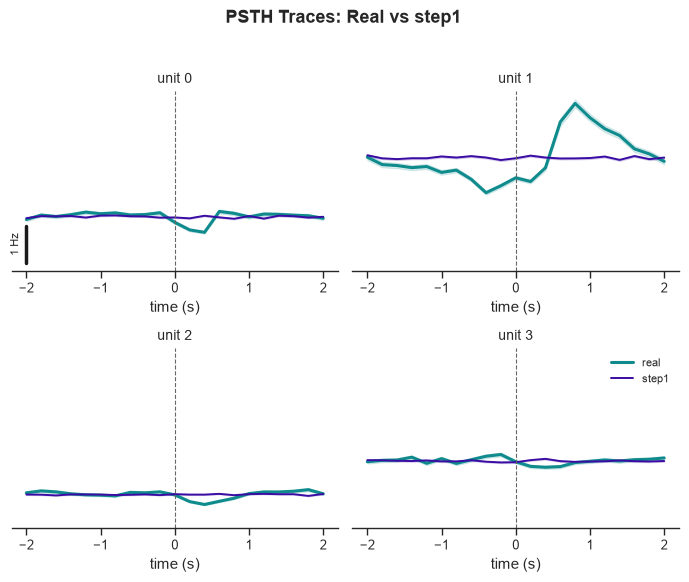

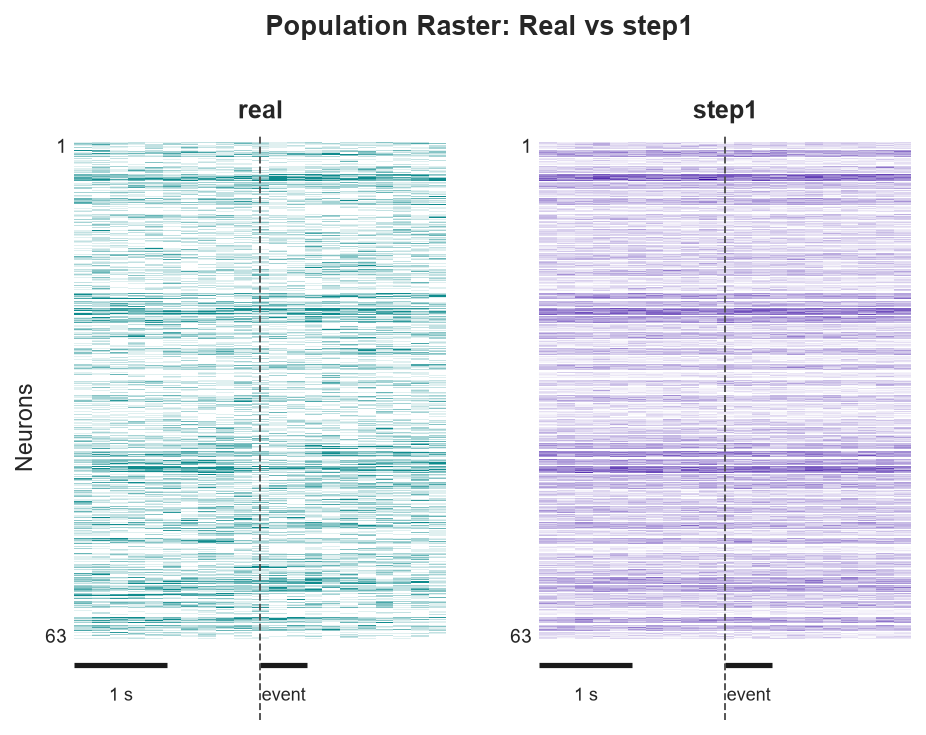

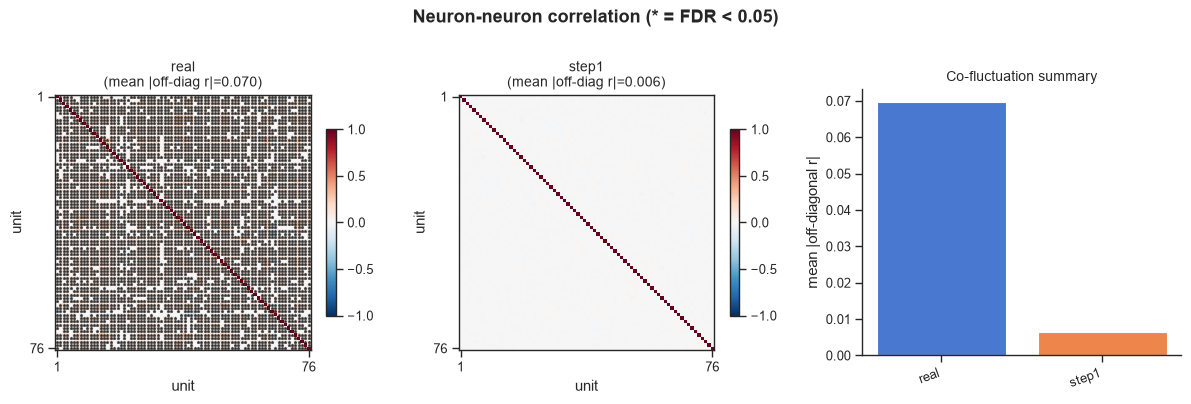

Generating plots for step2 vs real...


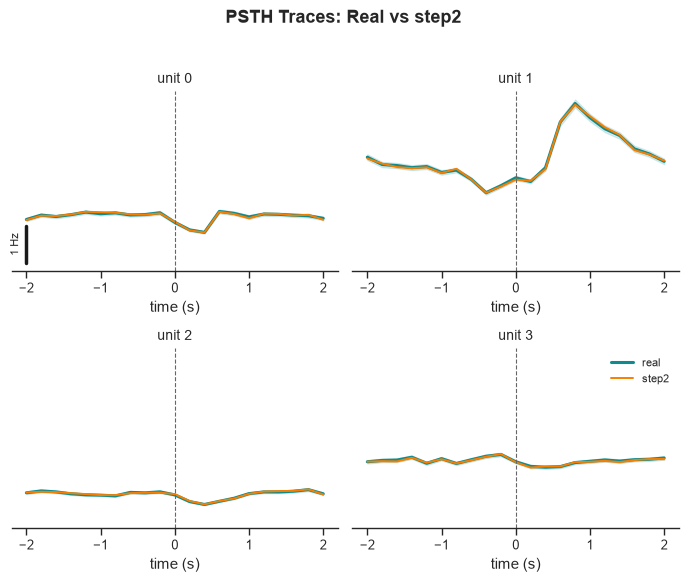

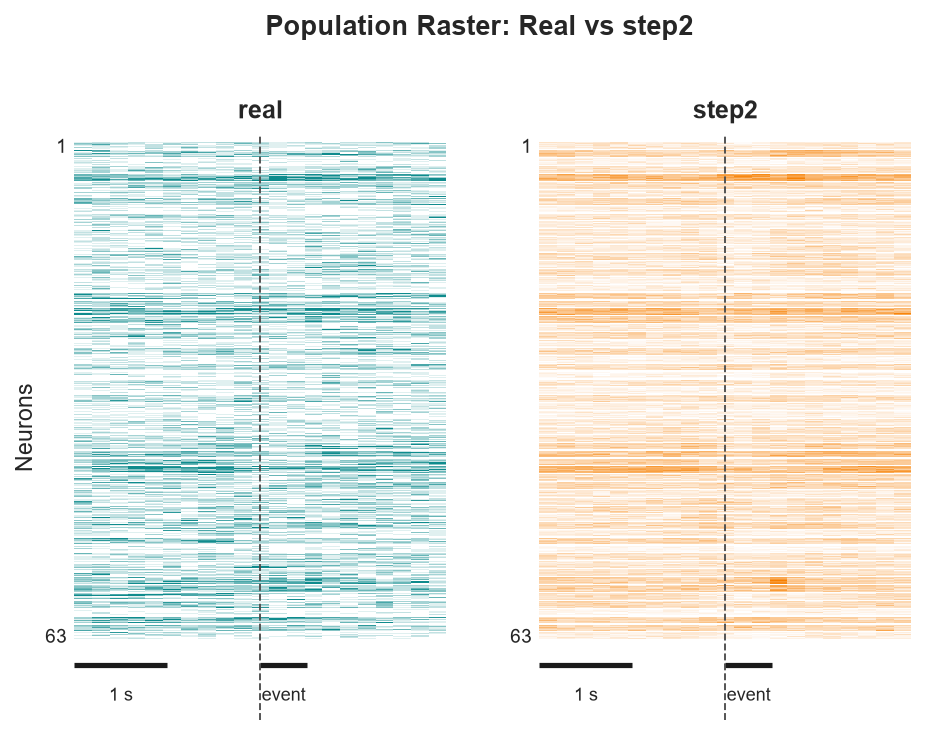

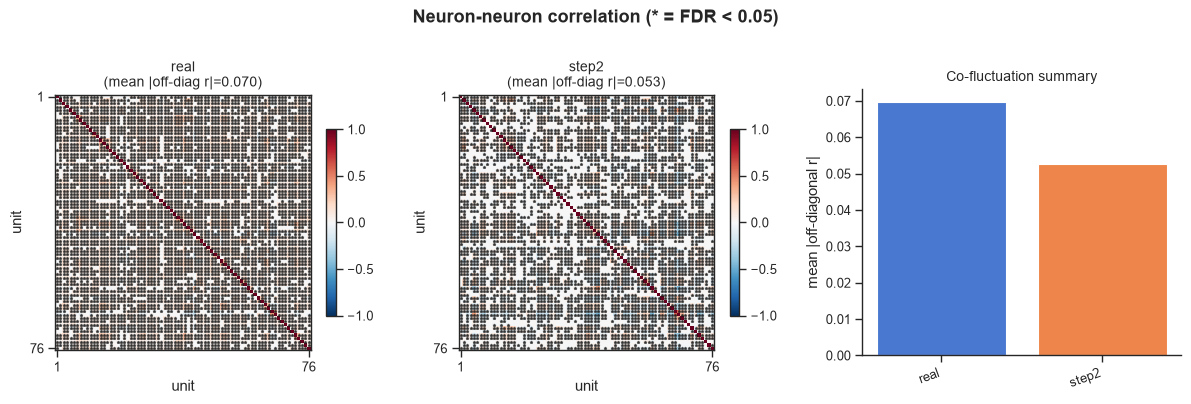

Generating plots for step3 vs real...


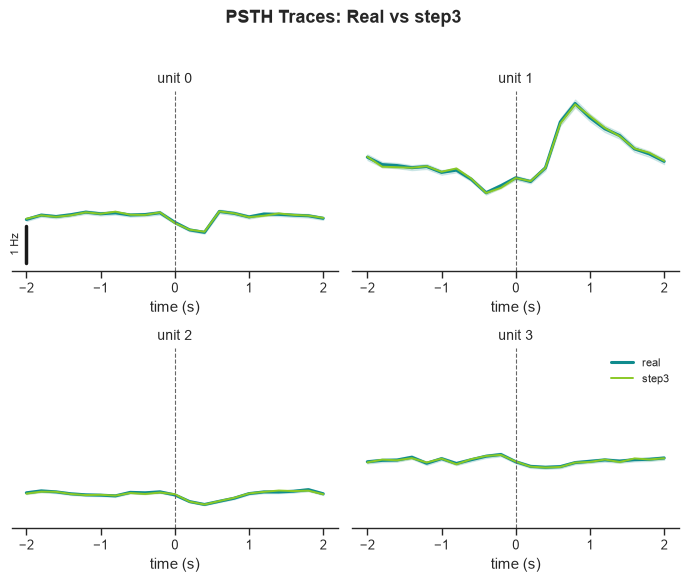

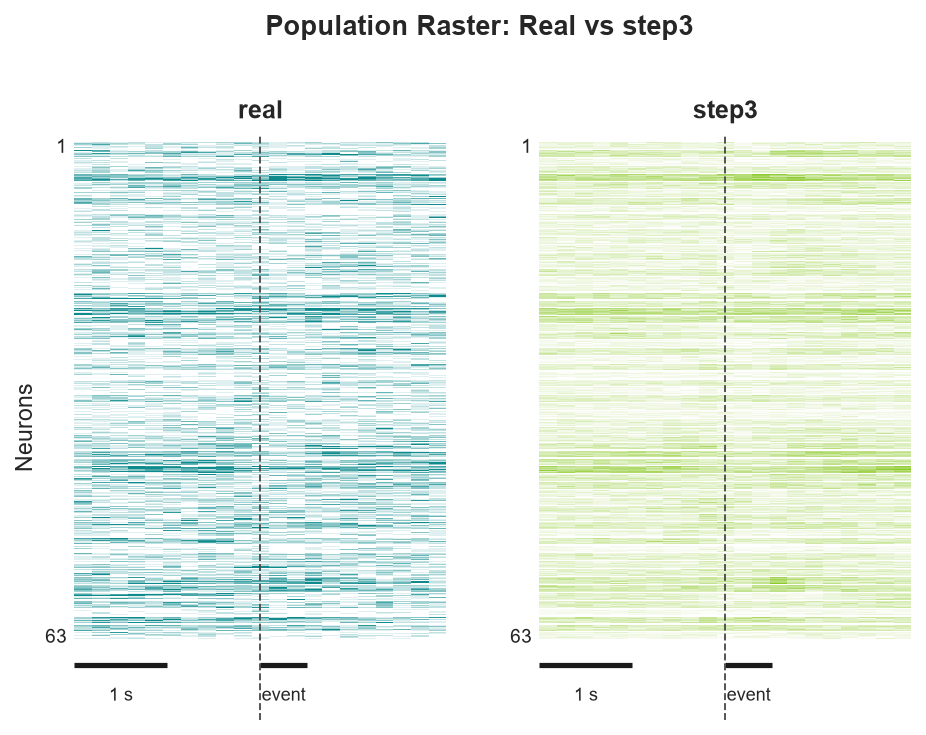

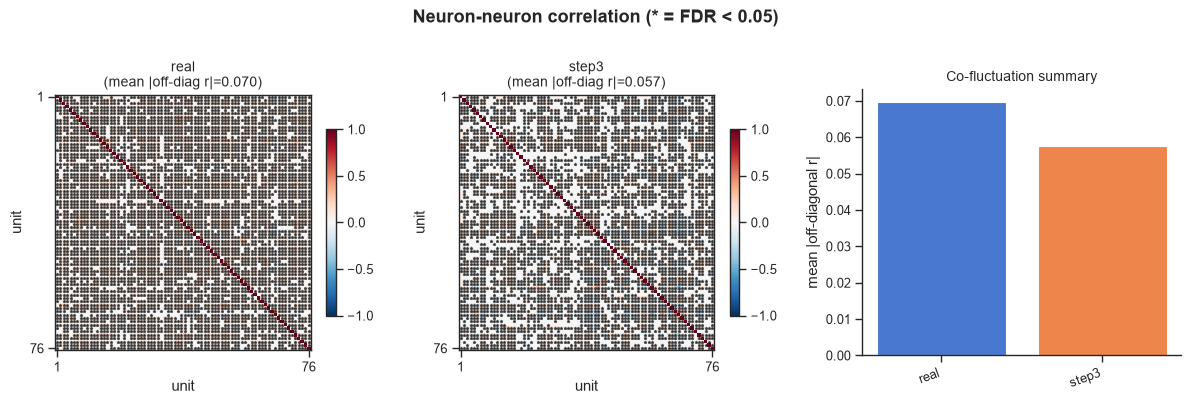

Generating plots for step4 vs real...


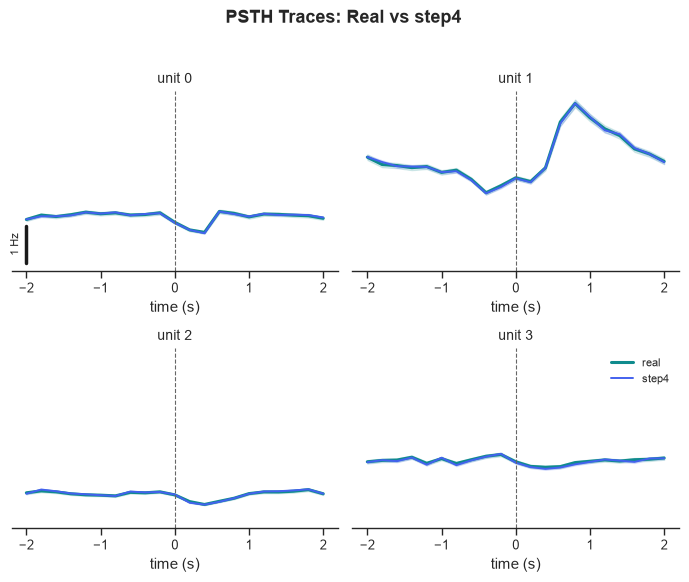

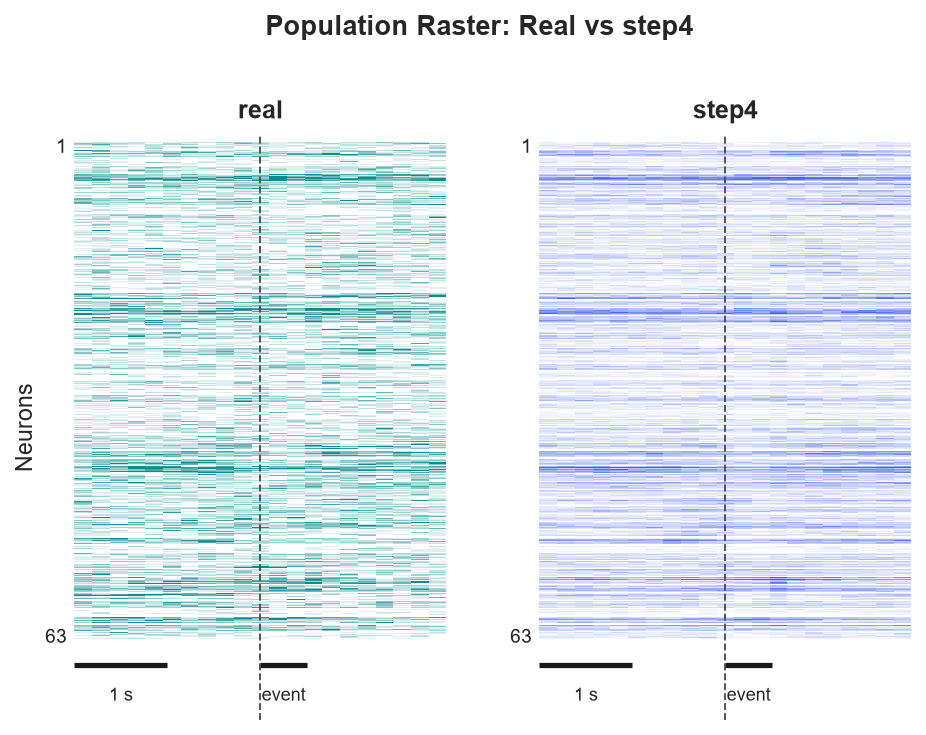

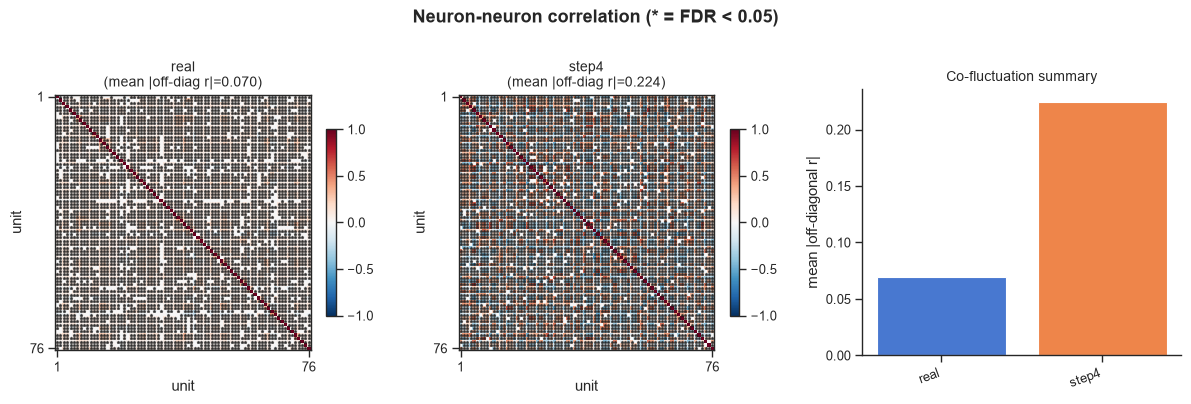

Generating plots for step5 vs real...


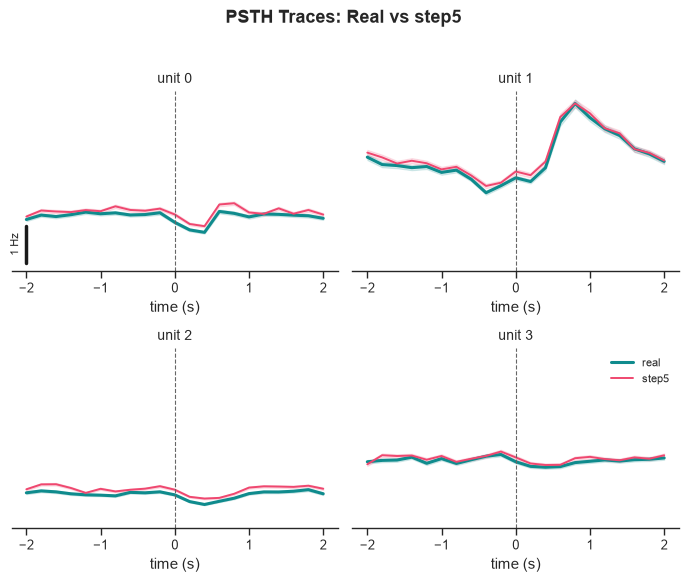

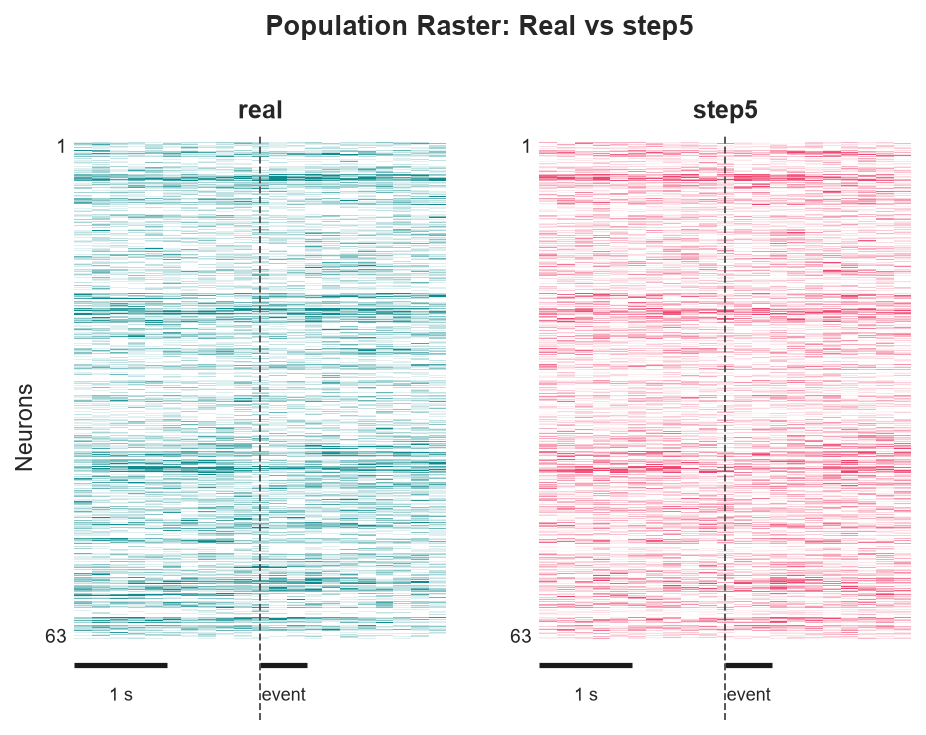

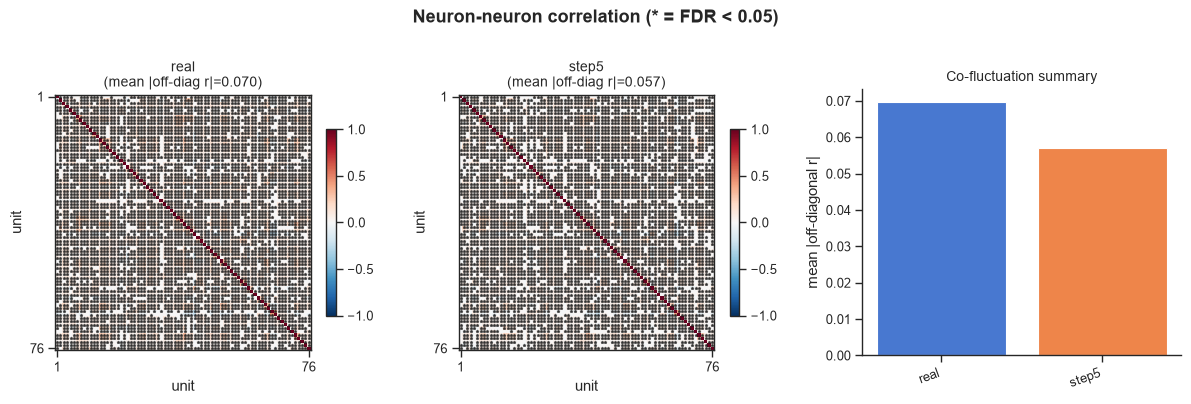

Generating plots for step6 vs real...


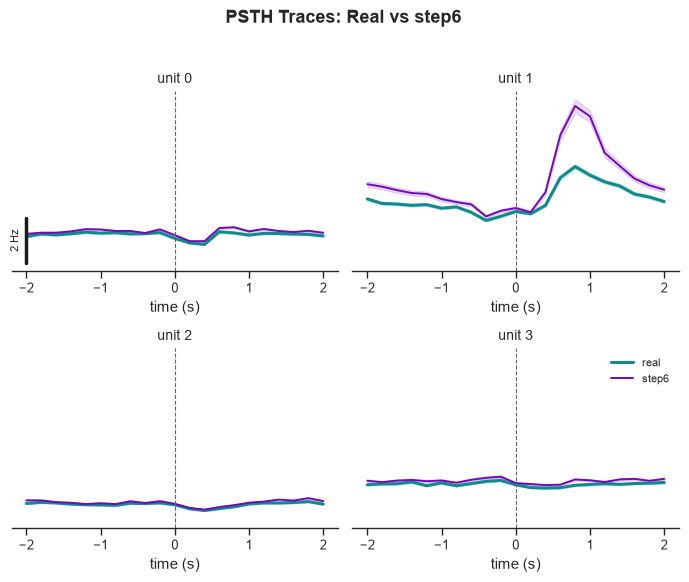

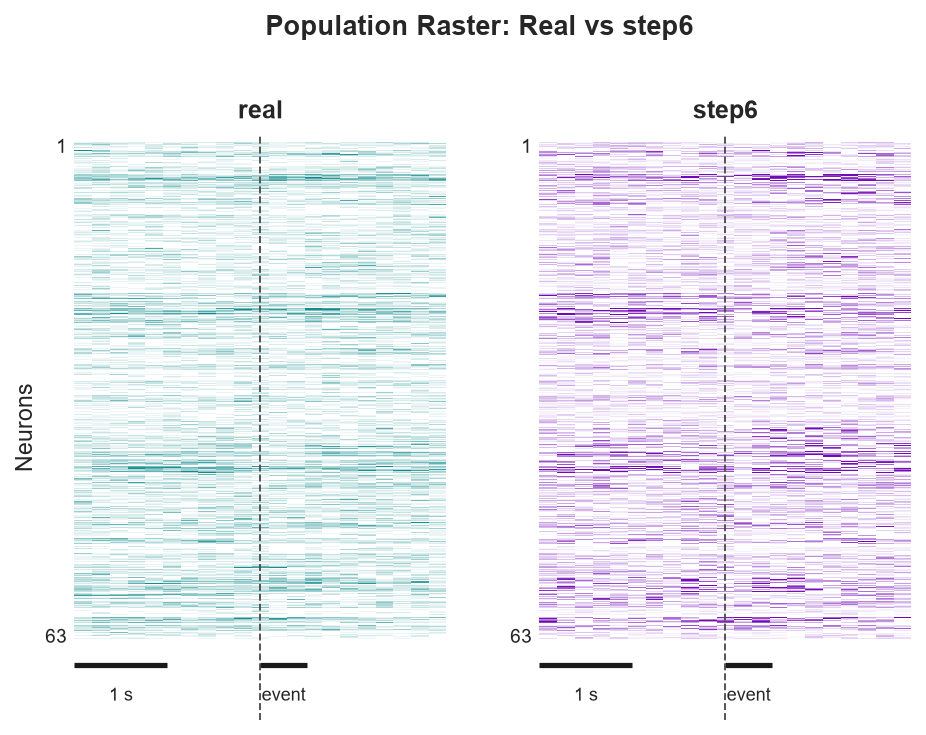

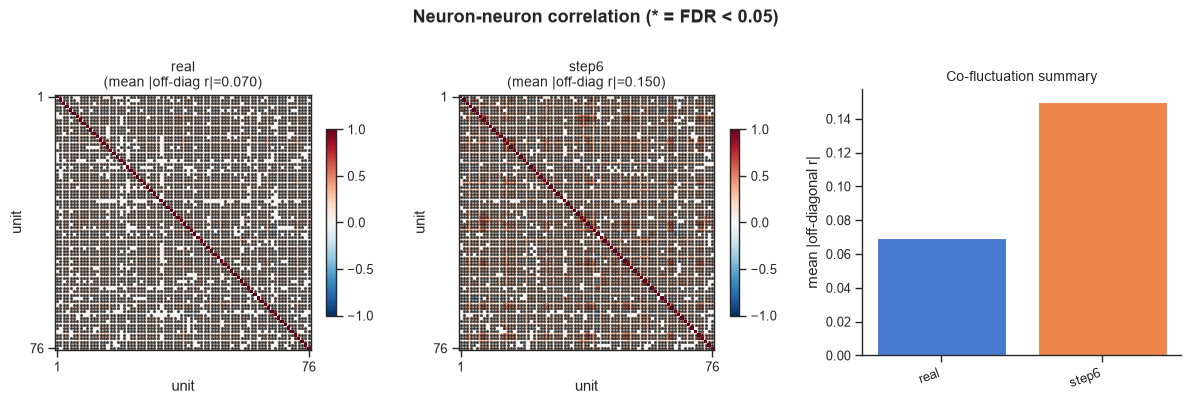

Generating plots for step7 vs real...


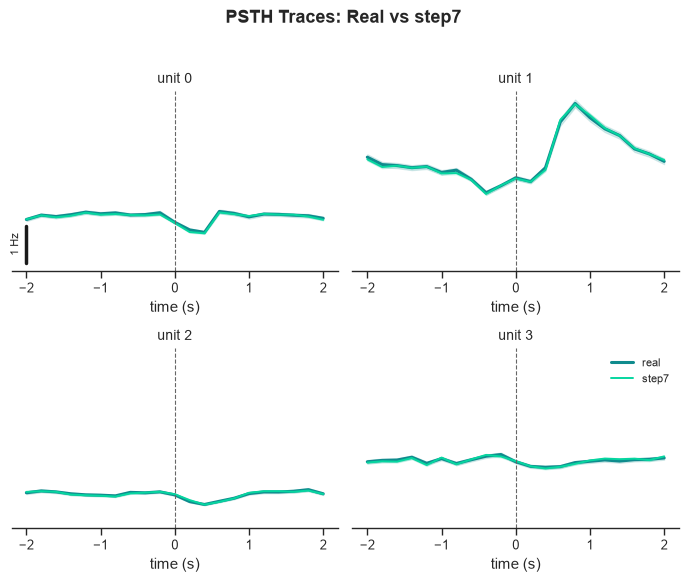

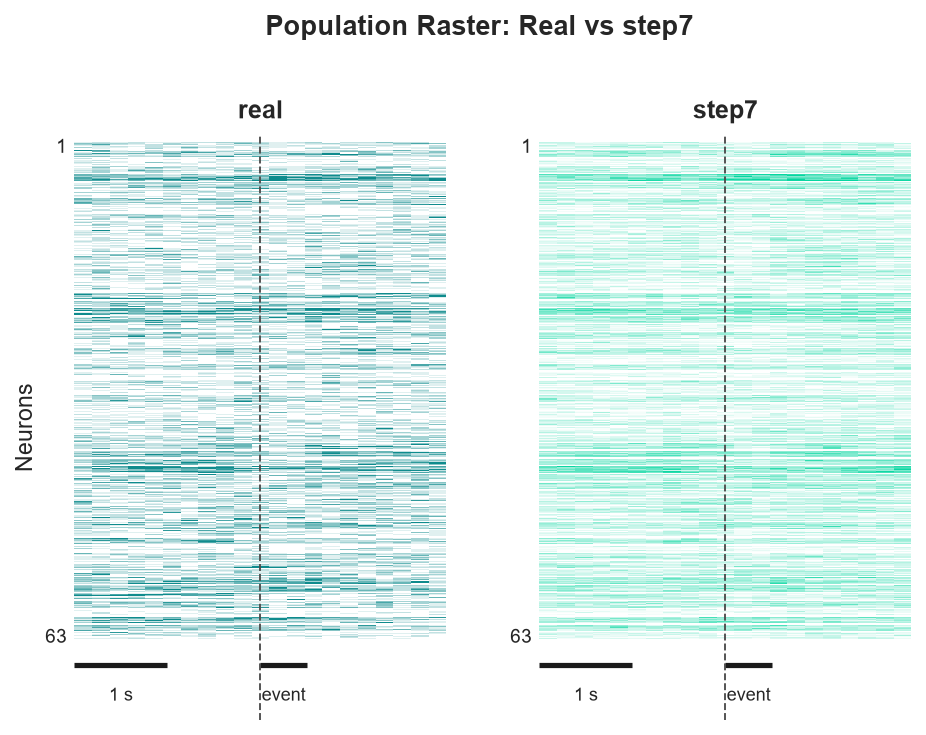

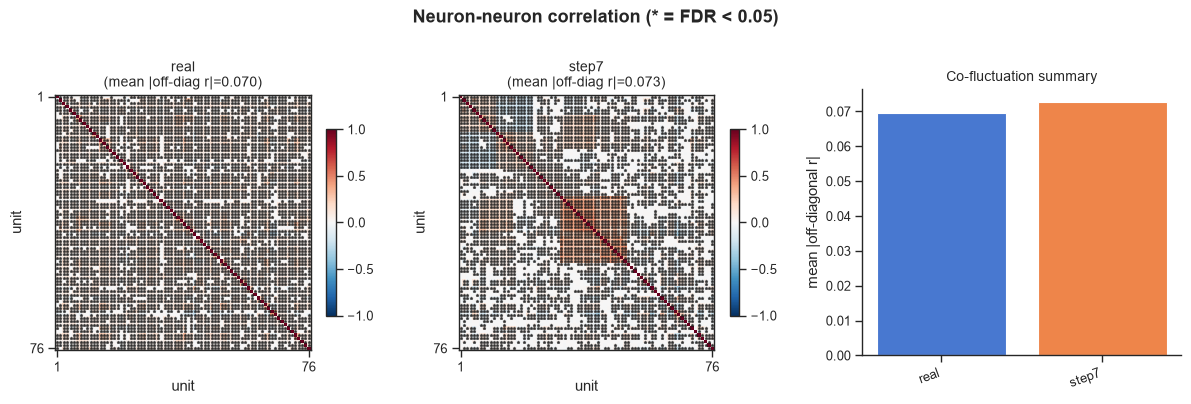

In [39]:
import importlib
import os
import src.plot_functions
importlib.reload(src.plot_functions)
from src.plot_functions import plot_psth_traces, plot_population_raster, plot_correlation_matrices

# Collect data for each step
prep['bin_centers'] = bin_times

conditions_vis = {
    'real': (prep['counts'] * prep['spike_scale'])
}

try: conditions_vis['step1'] = generate_step1(prep, seed=SEED)
except Exception as e: print("step1 skip:", e)

try: conditions_vis['step2'] = generate_step2_poisson_binwise(prep, seed=SEED)
except Exception as e: print("step2 skip:", e)

try: conditions_vis['step3'] = generate_step3_glm_poisson(prep, betas_step3, seed=SEED, X_dense=X_dense_step3, X_sparse=X_sparse_step3)
except Exception as e: print("step3 skip:", e)

try: conditions_vis['step4'] = generate_step4_random_latent_bias(prep, lambda_hat_step4, seed=SEED)
except Exception as e: print("step4 skip:", e)

try: conditions_vis['step5'] = generate_step5_shared_noise(prep, lambda_hat_step3, cov_type='global',seed=SEED, return_noise=True)[0]
except Exception as e: print("step5 skip:", e)

try: conditions_vis['step6'] = generate_step6_data(prep, empirical_covs, residuals_real, lambda_hat_step3, seed=SEED, return_noise=True)[0]
except Exception as e: print("step6 skip:", e)

try: conditions_vis['step7'] = generate_step7_kronecker_poisson(lambda_hat=lambda_hat_step3, per_neuron_cov=per_neuron_cov, per_bin_cov=per_bin_cov, ridge=1e-6, seed=SEED, spike_scale=spike_scale, return_noise=True)[0]
except Exception as e: print("step7 skip:", e)

# Plot for each step individually vs real
for step_name in conditions_vis.keys():
    if step_name == 'real':
        continue
        
    print(f"Generating plots for {step_name} vs real...")
    sub_conditions = {
        'real': conditions_vis['real'],
        step_name: conditions_vis[step_name]
    }
    
    # Create directory for the step
    save_dir = f"./plot/synthetic/{step_name}"
    os.makedirs(save_dir, exist_ok=True)
    
    # Plot PSTH Traces
    plot_psth_traces(
        sub_conditions, prep, 
        title=f"PSTH Traces: Real vs {step_name}",
        save_path=f"{save_dir}/psth_traces.png"
    )

    # Plot Population Raster
    plot_population_raster(
        sub_conditions, prep, 
        title=f"Population Raster: Real vs {step_name}",
        save_path=f"{save_dir}/population_raster.png"
    )

    # Plot Correlation Matrices
    plot_correlation_matrices(
        sub_conditions, prep,
        save_path=f"{save_dir}/correlation_matrices.png"
    )
